In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner 
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


#Another option for plotting
# pip install scienceplots
import scienceplots 
plt.style.use('science')


# #Some colors that Pablo likes:
colors = [
    "#1f77b4", # Vivid blue
    "#ff7f0e", # Bright orange
    "#2ca02c", # Rich green
    "#d62728", # Strong red
    "#9467bd", # Deep purple
    # "#8c564b", # Brownish-pink
    "#e377c2", # Pink
    "#7f7f7f", # Medium gray
    "#bcbd22", # Lime green
    "#17becf", # Cyan
    "#393b79", # Dark blue
    "#637939", # Olive green
    "#8c6d31", # Bronze
    # "#843c39", # Dark red
    # "#ad494a", # Reddish brown
    "#d6616b", # Soft red
    "#e7ba52", # Golden yellow
    "#7b4173", # Dark purple
    "#a55194", # Mauve
    "#ce6dbd", # Light purple
]

colors_sets = [
    "#ff7f0e",

    "#1f77b4",

    "#2ca02c",
    "#d62728",
    
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
    '#1f77b4',  # muted blue
    'r',  
] 

markers = [
    "o",  # Circle
    "^",  # Triangle up
    "s",  # Square
    "P",  # Plus (filled)
    "*",  # Star
    "X",  # X (filled)
    "D",  # Diamond
    "H",  # Hexagon
]


colors_models = colors


Selected_element=50
Selected_element_name="Sn"

color_train=colors_sets[9]
color_validation='orange'
color_test=colors_sets[3]

marker_train='s'
marker_validation='*'
marker_test='o'



size_train=30
size_validation=80
size_test=35

alpha_train=0.8
alpha_validation=0.9
alpha_test=0.4

models = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
PerfectM_params = [-15.835, 17.3, 9, 31.98, -58, - 4.5 * (163.5 ** 2) * (0.1605**2) / 223.5,0.57] # The perfect params of LDM model
key_list = models_selected

heterogeneous_data_type = ['BE', 'ChRad', 'CPn', 'CPp', 'PEn', 'PEp', 'QDB2n', 'QDB2p', 'QDB4n', 'QDB4p', 'MRadN', 'MRadP']
num_properties = 2

In [2]:
a = pd.read_csv('data/charge_radii.csv')
a.rename(columns = {'z' : 'Z', 'n' : 'N'}, inplace = True)

In [3]:
# This cell helps you to extract a dictionary that contains all the nuclei with BE and radius predictions of all the models we have
models_data_sets = {}
for model in models:
    Data_Values = pd.read_hdf("./data./selected_data.h5", key = model)
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : Data_Values["BE"], 'ChRad': Data_Values['ChRad']}


filtered_NZ = np.array([models_data_sets[models_selected[0]]['N'].tolist(), models_data_sets[models_selected[0]]['Z'].tolist() ]).T
filtered_NZ

array([[  2,   2],
       [  4,   2],
       [  6,   2],
       ...,
       [156, 108],
       [158, 108],
       [160, 110]])

In [4]:
models_data_sets['ME2']

{'N': 0        2
 1        4
 2        6
 3        2
 4        4
       ... 
 649    154
 650    156
 651    156
 652    158
 653    160
 Name: N, Length: 654, dtype: int64,
 'Z': 0        2
 1        2
 2        2
 3        4
 4        4
       ... 
 649    106
 650    106
 651    108
 652    108
 653    110
 Name: Z, Length: 654, dtype: int64,
 'BE': 0        21.670
 1        27.393
 2        28.549
 3        24.198
 4        49.397
          ...   
 649    1910.765
 650    1925.019
 651    1928.415
 652    1943.010
 653    1960.623
 Name: BE, Length: 654, dtype: float64,
 'ChRad': 0      2.145
 1      2.128
 2      2.142
 3      2.869
 4      2.552
        ...  
 649    6.097
 650    6.109
 651    6.123
 652    6.136
 653    6.162
 Name: ChRad, Length: 654, dtype: float64}

### The main objective of this trial is to see what will happen if we start our radius calibration from Zr or we feed for training datas in our analysis

## Necessary Functions

In [5]:
def separate_points_random(list1,random_chance):
    """
    Separates points in list1 into two groups randomly

    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]


    for i in range(len(list1)):
        point1=list1[i]
        val=np.random.rand()
        if val<=random_chance:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance(list1, list2, distance):
    """
    Separates points in list1 into two groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance_allSets(list1, list2, distance1, distance2):
    """
    Separates points in list1 into three groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    validation=[]
    test = []

    train_list_coordinates=[]
    validation_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance1:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            close2=False
            for point2 in list2:
                if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance2:
                    close2 = True
                    break
            if close2==True:
                validation.append(point1)
                validation_list_coordinates.append(i)
            else:
                test.append(point1)
                test_list_coordinates.append(i)                

    return np.array(train),np.array(validation), np.array(test), np.array(train_list_coordinates),  np.array(validation_list_coordinates),np.array(test_list_coordinates)

# In the cell below I have changed the function that filters nuclei so that we are now selecting ones with 30 proton and neutron higher

In [6]:
def LDM_extended(params, x): 
    #x = (n,z)
    #params= parameters (volume, surface, curv, sym, ssym, sym_2, Coulomb)
    
    n=x[0]
    z=x[1]
    A = n + z
    I = (n-z)/(n+z)


    return A*params[0] + params[1] * A ** (2/3) + params[2] * A ** (1/3)  +  params[3] * I ** 2*A + \
                + params[4] * (I ** 2) * A ** (2/3) + params[5] * (I ** 4)*A + params[6]*((z**2)/((A)**(1/3))) 

def filtered_NZ_extraction(filtered_NZ):
    #We want to create a function that takes only even-even nuclei with N,Z >= 8
    filtered_NZ_new = []
    for isotope in filtered_NZ:
        if ((isotope[0] >= 8) & (isotope[1] >=8)) & ((isotope[0]%2 == 0) & (isotope[1]%2 == 0)): # Sort the even-even isotope with proton and neutron number 8 or above
            filtered_NZ_new.append(isotope)
    filtered_NZ_new  = np.array(filtered_NZ_new)
    return filtered_NZ_new

def unified_NZ_extraction(models_data_sets, models_selected, filtered_NZ):
    #We want to create a function that extracts nuclei that exist in every models
    for model in models_selected:
        filtered_NZ_new = []
        for isotope in filtered_NZ:
            if ( (isotope[0] == models_data_sets[model]['N']) & (isotope[1] == models_data_sets[model]['Z']) ).any(): # Choose nuclei that are contained in each model
                filtered_NZ_new.append(isotope)
        filtered_NZ = np.array(filtered_NZ_new) #update our new list of isotope and repeat this for every model
    filtered_NZ_df = pd.DataFrame({'N' : filtered_NZ.T[0], 'Z' : filtered_NZ.T[1]})
    return filtered_NZ_new, filtered_NZ_df

def selected_models_data_sets_extraction(models_data_sets, models_selected, filtered_NZ_df, property):
    #We want to create dataframe that contains all the model predictions of a property of interest
    selected_models_data_sets = pd.DataFrame(filtered_NZ_df) #Initiate the dataframe by the proton and neutron number
    for model in models_selected:
        merged_df = pd.merge(filtered_NZ_df, pd.DataFrame(models_data_sets[model]), on = ['N', 'Z'], how  = 'inner') # Merge the isotope with their corresponding predictions
        selected_models_data_sets[model] = merged_df[property] # Choose the properties we want to perfrom BMM from
    return selected_models_data_sets

def models_output_extraction(selected_models_data_sets, train_coordinates, validation_coordinates, test_coordinates):
    #Technically rearrange the columns of the selected_models_data_sets and separate into intrapolation and extrapolation part
    models_output = selected_models_data_sets.copy()
    models_output['A'] = models_output['N'] + models_output['Z'] # Put the mass number in our dataframe
    cols = list(models_output.columns)
    cols[2], cols[-1] = cols[-1], cols[2] # Rearranging columns 
    models_output = models_output[cols]

    models_output_train = models_output.iloc[train_coordinates] # Training regions
    models_output_validation = models_output.iloc[validation_coordinates] # Validation regions
    models_output_test = models_output.iloc[test_coordinates] # Test regions
    return [models_output, models_output_train, models_output_validation, models_output_test]

def filtered_models_output_extraction(Selected_element, models_output, train_coordinates, validation_coordinates, test_coordinates):
    # Extract models output dataframe for a specific isotope and separate them into training, validation, and testing regions
    Z_range = (Selected_element, Selected_element) # Choose element we want to analyze
    N_range = (0,300)
    filtered_models_output = models_output[(models_output['Z'] >= Z_range[0]) & (models_output['Z'] <= Z_range[1]) & 
                         (models_output['N'] >= N_range[0]) & (models_output['N'] <= N_range[1])]  
    
    filtered_models_output_train = models_output.iloc[train_coordinates][(models_output.iloc[train_coordinates]['Z'] >= Z_range[0]) & (models_output.iloc[train_coordinates]['Z'] <= Z_range[1]) & 
                         (models_output.iloc[train_coordinates]['N'] >= N_range[0]) & (models_output.iloc[train_coordinates]['N'] <= N_range[1])]
    
    filtered_models_output_validation = models_output.iloc[validation_coordinates][(models_output.iloc[validation_coordinates]['Z'] >= Z_range[0]) & (models_output.iloc[validation_coordinates]['Z'] <= Z_range[1]) & 
                         (models_output.iloc[validation_coordinates]['N'] >= N_range[0]) & (models_output.iloc[validation_coordinates]['N'] <= N_range[1])]
    
    filtered_models_output_test = models_output.iloc[test_coordinates][(models_output.iloc[test_coordinates]['Z'] >= Z_range[0]) & (models_output.iloc[test_coordinates]['Z'] <= Z_range[1]) & 
                         (models_output.iloc[test_coordinates]['N'] >= N_range[0]) & (models_output.iloc[test_coordinates]['N'] <= N_range[1])]

    return [filtered_models_output, filtered_models_output_train, filtered_models_output_validation, filtered_models_output_test]

def filtered_models_output_stable_extraction(Selected_element, models_output, stable_coordinates):
    # Extract models output dataframe for stable isotope for a specific element
    Z_range = (Selected_element, Selected_element) # Choose element we want to analyze
    N_range = (0,300)
    stable_isotopes = []
    for isotope in stable_coordinates:
        if isotope[1] == Selected_element: #Choose isotope that has the same proton number
            stable_isotopes.append(isotope)
    stable_isotopes = np.array(stable_isotopes)
    
    filtered_models_output_stable = models_output[(models_output['Z'] >= Z_range[0]) & (models_output['Z'] <= Z_range[1])\
                                                 & (models_output['N'] >= N_range[0]) & (models_output['N'] <= N_range[1]) & models_output['N'].isin(stable_isotopes.T[0])]
    return filtered_models_output_stable

def filtered_models_output_dict_extraction(Selected_elements, key_name, models_output, train_coordinates, validation_coordinates, test_coordinates, stable_coordinates):
    # This functions helps me to create the filtered models output for different isotopes at the same time and store them in a dictionary
    filtered_models_output_dict = {} # Initiate dictionary
    for j in Selected_elements:
        key = f"{key_name}" + f"{int(j)}" # name is the key-value pair in the dictionary
        # The line below store the list of filtered models output for a specific element in the dictionary
        filtered_models_output_dict[key] = filtered_models_output_extraction(int(j), models_output, train_coordinates, validation_coordinates, test_coordinates)
        # The line below add to the list we have above the stable isotopes into our list
        filtered_models_output_dict[key].append(filtered_models_output_stable_extraction(int(j), models_output, stable_coordinates))
    filtered_models_output_dict.keys() # This is just to check if I had the right name for the list
    return filtered_models_output_dict

def models_PC_output(Vt_hat, model_predictions, predictions_mean, models_output):
    # This fucntions returns the dataframe of 
    models_PC = {}
    models_PC['N'] = models_output['N']
    models_PC['Z'] = models_output['Z']
    models_PC['A'] = models_output['N'] + models_output['Z']
    models_PC['PC_0'] = predictions_mean

    for i in range(len(Vt_hat)):
        models_PC['PC_' + str(i+1)] = Vt_hat[i].dot(model_predictions.T)
    model_PC = pd.DataFrame(models_PC)
    return model_PC

# Right now there are some more functions that we need for the statistical interference but we did not write it here yet
def USVt_hat_extraction(U,S,Vt, components_kept):
    U_hat = np.array([U.T[i] for i in range(components_kept)]).T
    S_hat = S[:components_kept]
    Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
    return U_hat, S_hat, Vt_hat

def super_params(X,y):
    X_T_X = X.T.dot(X)
    X_T_X_inv = np.linalg.inv(X_T_X)
    super_param = X_T_X_inv.dot(X.T).dot(y) 
    return super_param

def weights_params_translation(super_params, Vt_hat):
    model_weights = np.dot(super_params, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
    model_weights = np.array(model_weights)
    return model_weights

def residuals_calculator(model_weights, model_predictions_list, models_output_list):
    #Note that we for every models output list we put all nuclei first, and then train, validation, test region
    supermodel_full = model_weights.dot(model_predictions_list[0].T)
    supermodel_train = model_weights.dot(model_predictions_list[1].T)
    supermodel_validation = model_weights.dot(model_predictions_list[2].T)
    supermodel_test = model_weights.dot(model_predictions_list[3].T)

    supermodel_residuals_full = supermodel_full-models_output_list[0]['truth'].tolist()
    supermodel_residuals_train=supermodel_train-models_output_list[1]['truth'].tolist()
    supermodel_residuals_validation= supermodel_validation-models_output_list[2]['truth'].tolist()
    supermodel_residuals_test = supermodel_test-models_output_list[3]['truth'].tolist()

    return supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test

def supermodel_residuals_calculator(components_kept, model_predictions, predictions_mean, models_output, models_output_list, model_predictions_list, U, S, Vt):
    U_hat, S_hat, Vt_hat = USVt_hat_extraction(U,S,Vt, components_kept) # This gives you the approximation matrix
    # Note that we for any list that we create, we will put full dataset first, and then train, validation, test respectively
    # models_PC_train = models_PC_output(Vt_hat, model_predictions_list[1], predictions_mean) # This gives you the matrix of the PCs
    
    # key_list_PCs=list(models_PC_train.keys()) # columns' names of the PCs matrix

    models_PC_train = models_PC_output(Vt_hat, model_predictions, predictions_mean, models_output)
    X = models_PC_train.values[:,4:]# This is the matrix of the PCs
    # print(X.shape)
    y = models_output['truth'] - predictions_mean
    beta = super_params(X,y) #Calculate the best OLS beta
    model_weights = weights_params_translation(beta, Vt_hat) #Translate from the PCs' params to models' weights
    print(model_weights)

    supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test = residuals_calculator(model_weights,\
                                                                                                            model_predictions_list, models_output_list)

    return [supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test]

def PC_RMSE_calculator(components_kept, model_predictions, predictions_mean, models_output, models_output_list, model_predictions_list, U, S, Vt):
    # model_predictions and predictions_mean are variables that related to PCA decomposition, and models_output part are related to
    # the part where we want to calculate RMSE
    supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test = supermodel_residuals_calculator(\
                                                            components_kept, model_predictions, predictions_mean, models_output, models_output_list, model_predictions_list, U, S, Vt)
    sigma_train=np.sqrt(np.sum(supermodel_residuals_train**2) / len(supermodel_residuals_train) )
    sigma_validation=np.sqrt(np.sum(supermodel_residuals_validation**2) / len(supermodel_residuals_validation) )
    sigma_test=np.sqrt(np.sum(supermodel_residuals_test**2) / len(supermodel_residuals_test) )
    sigma_full=np.sqrt(np.sum(supermodel_residuals_full**2) / len(supermodel_residuals_full) )
    print(sigma_train)

    return [sigma_full,sigma_train,sigma_validation,sigma_test]


In [7]:
def plot_model_predictions(filtered_models_output_list, models_selected, Selected_element_name):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    i = 0
    for model in models_selected:
        plt.plot(filtered_models_output['N'], filtered_models_output[model],label = model, color=colors[i], alpha = 0.9,linewidth=5, zorder = 1)
        i+=1
    ax.scatter(x = filtered_models_output_train["N"], y = filtered_models_output_train['truth'], label = "Truth-Train",  alpha = 1,color=color_train,s=200,marker=marker_train,zorder=2)

    ax.scatter(x = filtered_models_output_validation["N"], y = filtered_models_output_validation['truth'], label = "Truth-Validation", alpha = 1,color=color_validation,s=350,marker=marker_validation,zorder=2)
    
    ax.scatter(x = filtered_models_output_test["N"], y = filtered_models_output_test['truth'], label = "Truth-Test", alpha = 1,color=color_test,s=350,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = filtered_models_output_stable['truth'], label = "Truth-Stable", alpha = 1,color='k',s=80,marker="s",zorder=2)
    
    
    
    plt.xlabel("N",fontsize=35)
    plt.ylabel(Selected_element_name+" R(fm)",fontsize=35)
    # plt.legend(fontsize=18,markerscale=1 )
    plt.legend(fontsize=15,markerscale=1,ncol=2  )
    # plt.savefig(f'{savefig}')
    plt.show()

def plot_filtered_real_data_dict(Selected_elements_list, element_name, filtered_models_output_dict):
    # Selected_element_list are the name of the elements, Selected_element is the number of proton that element has.
    i = Selected_elements_list.index(element_name)# This gives you the index of the element you want to graph
    dict_keys = list(filtered_models_output_dict.keys()) # This gives you all the keys in the dictionary that we input

    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)
    
    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    # This gives you the mean predictions of the isotope that we choose

    # color_local= "khaki"

    # This gives you training experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][1]["N"], y = filtered_models_output_dict[dict_keys[i]][1]['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    # This gives you validation experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][2]["N"], y = filtered_models_output_dict[dict_keys[i]][2]['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)
    # This gives you testing experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][3]["N"], y = filtered_models_output_dict[dict_keys[i]][3]['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    # This gives you stable experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][4]["N"], y = filtered_models_output_dict[dict_keys[i]][4]['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)

def plot_filtered_something_else_dict(Selected_elements_list, element_name, Selected_element, filtered_models_output_dict, filtered_models_something_else_dict, what_you_want_to_graph):
    # plot_filtered_real_data_dict(Selected_elements_list, element_name, filtered_models_output_dict) # This plots all the experimental data
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    index = Selected_elements_list.index(element_name) #Again, this gives you the index of the element you are trying to graph
    dict_keys = list(filtered_models_something_else_dict.keys()) # This gives you all the key of the dictionary that we want to create
    filtered_models_something_else = filtered_models_something_else_dict[dict_keys[index]][0][what_you_want_to_graph] #This is the dataframe that we want to graph from
    for i in range(len(filtered_models_something_else.columns)):
        column = list(filtered_models_something_else.columns)[i]
        plt.plot(filtered_models_something_else_dict[dict_keys[index]][0]['N'], filtered_models_something_else[column], color= colors[i], label= column,linewidth=5)

    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Selected_element}) $ {{\\cal R}}$ [fm]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
         
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    
    # plt.title(f'{title}', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    # plt.show()
# Let'steal this from Pablo like we always do
def plot_heatmap(xvals, yvals, zvals, quantity_of_interest, model):
    # Create scatter plot
    plt.rc("xtick", labelsize=10)
    plt.rc("ytick", labelsize=10)
    fig, ax = plt.subplots(figsize = (4,3), dpi = 200)
    
    sc = ax.scatter(xvals, yvals, c=zvals, s=0.5, cmap='plasma', marker = 's')
    # plt.colorbar(sc, label='Z-Value')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f'{quantity_of_interest}', fontsize=10) 
    cbar.ax.tick_params(labelsize=10) 
    
    plt.xlabel('Neutrons',fontsize=10)
    plt.ylabel('Protons',fontsize=10)

    ax.grid(True)
    ax.axis('equal')
    plt.title(f'{model}')
    plt.tight_layout()
    # plt.savefig(f'{savefig}')
    plt.show()

def plot_heatmap_3D(xvals, yvals, zvals, title, elev=30, azim=-60):
    # Create figure and 3D axes
    fig, ax_3d = plt.subplots(figsize=(4, 3), dpi=200, subplot_kw={'projection': '3d'})
    
    # Normalize z values
    # z_normalized = (zvals - zvals.min()) / (zvals.max() - zvals.min())
    z_normalized = zvals # This is when we want to see the actual components of the PCs
    # Define the size of the bars
    dx = dy = 1.5  # Width of the bars in the x and y directions
    dz = z_normalized  # Height of the bars (z values)

    # Create 3D bar plot
    ax_3d.bar3d(xvals, yvals, np.zeros_like(z_normalized), dx, dy, dz, color=plt.cm.plasma((zvals - zvals.min()) / (zvals.max() - zvals.min())))
    ax_3d.set_zlim(np.minimum(0, zvals.min()), zvals.max())
    # Set view angle
    ax_3d.view_init(elev=elev, azim=azim) 
    
    ax_3d.tick_params(axis='both', labelsize=8)  # Smaller font size for major ticks
    ax_3d.tick_params(axis='z', labelsize=8)
    
    # Set labels and title
    ax_3d.set_xlabel('Neutrons', fontsize = 5)
    ax_3d.set_ylabel('Protons', fontsize = 5)
    ax_3d.set_zlabel('Scaled Z', fontsize = 5)
    ax_3d.set_title(title)

    # Create a colorbar based on the plasma colormap and the normalization
    mappable = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=zvals.min(), vmax=zvals.max()))
    mappable.set_array(zvals)
    
    # Add the colorbar to the plot
    cbar = plt.colorbar(mappable, ax=ax_3d, shrink=0.5, aspect=10, location='right', pad=0.2)
    cbar.set_label(title, fontsize=5)
    cbar.ax.tick_params(labelsize=5)

    # Show plot
    # plt.show()

In [688]:
def Plotter2D_single(xvals, yvals, zvals, validation_set,quantity_of_interest, model):
    # xvals,yvals,zvals = data
    #A plotter to see principal components in 2D
    plt.rc("xtick", labelsize=25)
    plt.rc("ytick", labelsize=25)
    
    fig, ax = plt.subplots(figsize=(12, 8), dpi=200)

    # Create scatter plot
    sc = ax.scatter(xvals, yvals, c=zvals, s=25, cmap='plasma',marker='s')
    # plt.colorbar(sc, label='Z-Value')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f'{quantity_of_interest}', fontsize=25)
    ax.scatter(validation_set.T[0], validation_set.T[1], color = 'black', alpha = 1, marker = 'o', s = 35)
    cbar.ax.tick_params(labelsize=20) 
    plt.xlabel('Neutrons',fontsize=25)
    plt.ylabel('Protons',fontsize=25)

    ax.grid(True)
    # ax.axis('equal')
    plt.title(f'{model}', fontsize = 25)
    # plt.show()

def Plotter3D_single(xvals, yvals, zvals, title, elev=30, azim=-60):
    # xvals,yvals,zvals = data
    #A plotter to see principal components in 3D
    plt.rc("xtick", labelsize=15)
    plt.rc("ytick", labelsize=15)

    z_min = zvals.min()
    z_max = zvals.max()
    z_normalized = zvals

    # Create figure for 3D plot
    fig = plt.figure(figsize=(8, 6), dpi=200)
    ax = fig.add_subplot(111, projection='3d')



    # Define the size of the bars
    dx = dy = 1.5  # Width of the bars in the x and y direction
    dz = z_normalized        # Height of the bars (z values)

    # Create 3D bar plot
    ax.bar3d(xvals, yvals, np.zeros_like(zvals), dx, dy, dz, color=plt.cm.plasma((zvals - zvals.min()) / (zvals.max() - zvals.min())))
    ax.set_zlim(np.minimum(0, zvals.min()), zvals.max())
    ax.view_init(elev=elev, azim=azim) 

    # Setting labels and title
    ax.set_xlabel('Neutrons')
    ax.set_ylabel('Protons')
    ax.set_zlabel('Z value')
    ax.set_title(title)

    mappable = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=zvals.min(), vmax=zvals.max()))
    mappable.set_array(zvals)

    # Add the colorbar to the plot
    cbar = plt.colorbar(mappable, ax=ax, shrink=0.5, aspect=10, location='right', pad=0.2)
    cbar.set_label(title, fontsize=20)
    cbar.ax.tick_params(labelsize=20)
    
    # plt.show()



def Plotter2D(ax, xvals, yvals, zvals, validation_set, quantity_of_interest, model):
    #A plotter to see principal components in 2D, part of the big plotter


    # Create scatter plot
    sc = ax.scatter(xvals, yvals, c=zvals, s=25, cmap='plasma',marker='s')
    # plt.colorbar(sc, label='Z-Value')
    cbar = plt.colorbar(sc, ax=ax)
    ax.scatter(validation_set.T[0], validation_set.T[1], color = 'black', alpha = 1, marker = 'o', s = 35)
    cbar.set_label(f'{quantity_of_interest}', fontsize=25) 
    cbar.ax.tick_params(labelsize=20) 




    plt.xlabel('Neutrons',fontsize=25)
    plt.ylabel('Protons',fontsize=25)

    plt.title(f'{model}', fontsize = 25)
    ax.grid(True)
    ax.axis('equal')

    # plt.show()

def Plotter3D(ax,xvals,yvals,zvals,elev=30,azim=-60):
    #A plotter to see principal components in 3D, part of the big plotter
    z_min = zvals.min()
    z_max = zvals.max()
    z_normalized = zvals

    # Create figure for 3D plot
    # fig = plt.figure(figsize=(8, 6), dpi=200)
    # ax = fig.add_subplot(111, projection='3d')



    # Define the size of the bars
    dx = dy = 1.5  # Width of the bars in the x and y direction
    dz = z_normalized        # Height of the bars (z values)

    # Create 3D bar plot
    ax.bar3d(xvals, yvals, np.zeros_like(zvals), dx, dy, dz, color=plt.cm.plasma((zvals - zvals.min()) / (zvals.max() - zvals.min())))
    ax.set_zlim(np.minimum(0, zvals.min()), zvals.max())
    ax.view_init(elev=elev, azim=azim) 

    # Setting labels and title
    ax.set_xlabel('Neutrons')
    ax.set_ylabel('Protons')
    ax.set_zlabel('Scaled Z')


    # plt.show()    



def PlotMultiple(xvals, yvals, zvals, validation_set, quantity_of_interest, model, angles_sheet=None):
    # Determine the number of rows needed for the plots
    # n_rows = len(data_sets)
    # Each data_sets element should look like [x,y,z]

    # Create a figure with subplots
    fig = plt.figure(figsize=(20, 8), dpi=200)


    # 2D plot
    ax_2d = fig.add_subplot(1, 2, 1)
    Plotter2D(ax_2d, xvals, yvals, zvals, validation_set, quantity_of_interest, model)

    # 3D plot
    ax_3d = fig.add_subplot(1, 2, 2, projection='3d')
    if angles_sheet == None:
        Plotter3D(ax_3d, xvals, yvals, zvals)
    else:
        Plotter3D(ax_3d, xvals, yvals, zvals,elev=angles_sheet[0],azim=angles_sheet[1])

    plt.tight_layout()
    # plt.show()


In [8]:
stable_coordinates_full=np.loadtxt("Stable-Isotopes.txt")
stable_coordinates = filtered_NZ_extraction(stable_coordinates_full) # Make sure that nuclei we analyze have proton and neutron number of 8 or above

In [9]:
filtered_NZ = filtered_NZ_extraction(filtered_NZ) # This one will choose even-even isotope with N,Z >= 8
filtered_NZ, filtered_NZ_df = unified_NZ_extraction(models_data_sets, models_selected, filtered_NZ)

In [10]:
#Let's create a dataframe that contains all the model predictions
selected_models_data_sets_mass = selected_models_data_sets_extraction(models_data_sets, models_selected, filtered_NZ_df, 'BE')
selected_models_data_sets_radius = selected_models_data_sets_extraction(models_data_sets, models_selected, filtered_NZ_df, 'ChRad')

# This dataset does not yet contain the real data, let's now merge this dataset with the real data
truth_BE = pd.read_hdf("./data./selected_data.h5", key = 'AME2020')
truth_BE_df = pd.DataFrame(truth_BE)
selected_models_data_sets_mass = pd.merge(selected_models_data_sets_mass, truth_BE[['N', 'Z', 'BE']], on = ['N', 'Z'], how = 'inner') #Add real data to the dataframe
selected_models_data_sets_mass.rename(columns = {'BE' : 'truth'}, inplace = True) #Rename our truth column
cols_mass = list(selected_models_data_sets_mass.keys())
cols_mass.remove('truth')
cols_mass.insert(2, 'truth') # These 2 lines rearrange the order fo the column
selected_models_data_sets_mass = selected_models_data_sets_mass[cols_mass]

# This is for the radius data
truth_CR_df = a
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, truth_CR_df[['N', 'Z',  'radius_val']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius.rename(columns = {'radius_val' : 'truth'}, inplace = True)
cols_radius = list(selected_models_data_sets_radius.keys())
# The next 2 lines help you to transition the truth column to the start of the dataframe
cols_radius.remove('truth')
cols_radius.insert(2, 'truth')
selected_models_data_sets_radius = selected_models_data_sets_radius[cols_radius]
selected_models_data_sets_radius = selected_models_data_sets_radius.copy().dropna().reset_index(drop = True)
selected_models_data_sets_radius

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1
0,8,8,2.6991,2.729,2.691,2.747,2.735,2.794203,2.824011,2.795792,2.817382,2.793546,2.790816
1,10,8,2.7726,2.733,2.704,2.749,2.728,2.793734,2.825080,2.799074,2.807857,2.785015,2.781329
2,8,10,2.9714,2.956,2.912,2.945,2.955,2.956188,2.987489,2.964309,2.991813,2.966094,2.973445
3,10,10,3.0055,2.986,2.942,2.975,2.973,2.942506,2.973045,2.951974,2.974810,2.935663,2.967315
4,12,10,2.9525,2.960,2.949,2.978,2.941,2.964141,2.972133,2.976913,2.981346,2.925008,2.968485
...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,150,94,5.8948,5.933,5.920,5.930,5.942,5.910061,5.918577,5.915247,5.902641,5.908618,5.923415
341,146,96,5.8285,5.935,5.921,5.933,5.936,5.919476,5.928108,5.924384,5.908823,5.911968,5.928126
342,148,96,5.8429,5.948,5.938,5.947,5.951,5.929864,5.939063,5.934703,5.920200,5.923912,5.940104
343,150,96,5.8562,5.958,5.945,5.956,5.964,5.939141,5.949234,5.944656,5.930929,5.935161,5.951470


In [11]:
selected_models_data_sets_radius[(selected_models_data_sets_radius['N'] == 64) & (selected_models_data_sets_radius['Z'] == 50)]

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1
122,64,50,4.6099,4.602,4.589,4.604,4.59,4.614445,4.631425,4.629658,4.605224,4.60989,4.607308


### Now we have 2 data sets separately for mass and radius, let's execute the usual analysis that we already did

In [12]:
filtered_NZ_df_radius = selected_models_data_sets_radius[['N', 'Z']]
filtered_NZ_radius = np.array(filtered_NZ_df_radius)
Full_set_radius = filtered_NZ_radius.copy()

filtered_NZ_df_mass = selected_models_data_sets_mass[['N', 'Z']]
filtered_NZ_mass = np.array(filtered_NZ_df_mass)
Full_set_mass = filtered_NZ_mass.copy()

In [13]:
filtered_NZ_df_radius

,N,Z
0,8,8
1,10,8
2,8,10
3,10,10
4,12,10
...,...,...
340,150,94
341,146,96
342,148,96
343,150,96


In [14]:
PerfectM_params
LDM_mass = -LDM_extended(PerfectM_params, filtered_NZ_mass.T)

+ What we want to first try is to try our scaling scheme in which we divide our dataset by the number $A^{(1/3)} * 1.2$

In [15]:
normalized_selected_models_data_sets_radius = filtered_NZ_df_radius.copy()
normalized_selected_models_data_sets_mass = filtered_NZ_df_mass.copy()

mass_num_radius = (filtered_NZ_df_radius['N'] + filtered_NZ_df_radius['Z']).values
simple_model_radius = 1.2 * mass_num_radius ** (1/3)
for model in list(selected_models_data_sets_radius.iloc[:,2:].columns):
    normalized_selected_models_data_sets_radius[model] = selected_models_data_sets_radius[model].copy()/simple_model_radius
    normalized_selected_models_data_sets_mass[model] = selected_models_data_sets_mass[model].copy()/LDM_mass
normalized_selected_models_data_sets_mass

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1
0,8,8,1.199924,1.191637,1.213150,1.198379,1.204575,1.211556,1.212012,1.220798,1.197563,1.191360,1.144320
1,10,8,1.104749,1.107500,1.122008,1.117512,1.119819,1.143772,1.141706,1.143678,1.121783,1.122390,1.075633
2,12,8,1.056200,1.055171,1.066119,1.069064,1.070578,1.105665,1.094421,1.091906,1.072771,1.075386,1.030026
3,14,8,1.028542,1.018930,1.027633,1.036640,1.036691,1.082241,1.061879,1.056829,1.040150,1.042288,0.998022
4,16,8,0.994195,0.985484,0.991327,1.004879,1.006068,1.052782,1.026370,1.019800,1.005835,1.007400,0.965045
...,...,...,...,...,...,...,...,...,...,...,...,...,...
624,154,106,0.886786,0.887575,0.886204,0.887186,0.889167,0.879995,0.882982,0.881943,0.883640,0.886049,0.886686
625,156,106,0.887131,0.887884,0.886370,0.887580,0.889278,0.880597,0.883434,0.882079,0.883989,0.886438,0.886867
626,156,108,0.884579,0.885334,0.883966,0.884908,0.887161,0.877651,0.880709,0.879696,0.881344,0.883975,0.884320
627,158,108,0.884957,0.885719,0.884206,0.885385,0.887309,0.878527,0.881228,0.880094,0.881865,0.884465,0.884717


In [16]:
radius_std = np.std(normalized_selected_models_data_sets_radius['truth'])
selected_models_data_sets_radius_unit_variance = normalized_selected_models_data_sets_radius.copy()
predictions_name_list = selected_models_data_sets_radius_unit_variance.columns[2:]
selected_models_data_sets_radius_unit_variance[predictions_name_list] = normalized_selected_models_data_sets_radius.copy()[predictions_name_list]/radius_std

mass_std = np.std(normalized_selected_models_data_sets_mass['truth'])
selected_models_data_sets_mass_unit_variance = normalized_selected_models_data_sets_mass.copy()
predictions_name_list = selected_models_data_sets_mass_unit_variance.columns[2:]
selected_models_data_sets_mass_unit_variance[predictions_name_list] = normalized_selected_models_data_sets_mass.copy()[predictions_name_list]/mass_std

In [17]:
### After scaling and making unit variance with our dataset, let's see if there is any difference in the PCA decomposition

### We now need to separate these nuclei to interpolation and extrapolation regions

In [18]:
stable_coordinates_df = pd.DataFrame({'N' : stable_coordinates.T[0], 'Z' : stable_coordinates.T[1]})
stable_coordinates_radius_df = pd.merge(filtered_NZ_df_radius, stable_coordinates_df, how = 'inner')
stable_coordinates_radius = stable_coordinates_radius_df.values

In [19]:
#Traditional way with stable coordinates to seperate our data points for nuclei - radius data sets

distance1=1.75
distance2=2.5

training_set_radius, validation_set_radius, test_set_radius, train_coordinates_radius, validation_coordinates_radius,test_coordinates_radius=separate_points_distance_allSets(filtered_NZ_radius, stable_coordinates, distance1,distance2)

In [20]:
#Traditional way with stable coordinates to seperate our data points for nuclei - mass data sets

distance1=2
distance2=3

training_set_mass, validation_set_mass, test_set_mass, train_coordinates_mass, validation_coordinates_mass,test_coordinates_mass=separate_points_distance_allSets(filtered_NZ_mass, stable_coordinates, distance1,distance2)

In [21]:
# After having separated our data points into intrapolation and extrapolation part, first we have to extract all the model predictions and perform
# PCA on that data set

In [22]:
#Extract models output of different categories (mass and radius) and classify them into 4 regions: all,train, validation, test
models_output_mass_list = models_output_extraction(selected_models_data_sets_mass_unit_variance, train_coordinates_mass, validation_coordinates_mass, test_coordinates_mass)
models_output_radius_list = models_output_extraction(selected_models_data_sets_radius_unit_variance, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)

In [23]:
#Separate them for further use
[models_output_mass, models_output_mass_train, models_output_mass_validation, models_output_mass_test] = models_output_mass_list
[models_output_radius, models_output_radius_train, models_output_radius_validation, models_output_radius_test] = models_output_radius_list

In [24]:
models_output_mass

,N,Z,A,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,truth
0,8,8,16,29.810820,30.348994,29.979469,30.134477,30.309110,30.320531,30.540326,29.959061,29.803879,28.627085,30.018119
1,10,8,18,27.705984,28.068924,27.956444,28.014167,28.613384,28.561709,28.611039,28.063299,28.078480,26.908778,27.637145
2,12,8,20,26.396892,26.670769,26.744431,26.782309,27.660078,27.378787,27.315859,26.837178,26.902590,25.767838,26.422624
3,14,8,22,25.490242,25.707963,25.933308,25.934578,27.074074,26.564700,26.438356,26.021106,26.074597,24.967196,25.730702
4,16,8,24,24.653534,24.799714,25.138738,25.168474,26.337111,25.676382,25.512020,25.162656,25.201802,24.142219,24.871471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
624,154,106,260,22.204187,22.169883,22.194460,22.244022,22.014549,22.089270,22.063278,22.105738,22.166011,22.181949,22.184448
625,156,106,262,22.211906,22.174048,22.204313,22.246787,22.029621,22.100592,22.066694,22.114485,22.175737,22.186475,22.193080
626,156,108,264,22.148123,22.113908,22.137476,22.193833,21.955929,22.032430,22.007072,22.048298,22.114125,22.122763,22.129245
627,158,108,266,22.157758,22.119909,22.149388,22.197535,21.977823,22.045400,22.017025,22.061328,22.126387,22.132694,22.138685


In [25]:
filtered_models_output_mass_list_50 = filtered_models_output_extraction(50, models_output_mass, train_coordinates_mass, validation_coordinates_mass, test_coordinates_mass)
filtered_models_output_radius_list_20 = filtered_models_output_extraction(20, models_output_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)

filtered_models_output_mass_stable_50 = filtered_models_output_stable_extraction(50, models_output_mass, stable_coordinates)
filtered_models_output_radius_stable_20 = filtered_models_output_stable_extraction(20, models_output_radius, stable_coordinates_radius)

[filtered_models_output_mass_50, filtered_models_output_mass_train_50, filtered_models_output_mass_validation_50, filtered_models_output_mass_test_50] = filtered_models_output_mass_list_50
[filtered_models_output_radius_50, filtered_models_output_radius_train_20, filtered_models_output_radius_validation_20, filtered_models_output_radius_test_20] = filtered_models_output_radius_list_20

model_predictions_mass=models_output_mass[key_list].values
model_predictions_mass_train=models_output_mass_train[key_list].values
model_predictions_mass_validation=models_output_mass_validation[key_list].values
model_predictions_mass_test=models_output_mass_test[key_list].values
model_predictions_mass_list = [model_predictions_mass, model_predictions_mass_train, model_predictions_mass_validation, model_predictions_mass_test]

model_predictions_radius=models_output_radius[key_list].values
model_predictions_radius_train=models_output_radius_train[key_list].values
model_predictions_radius_validation=models_output_radius_validation[key_list].values
model_predictions_radius_test=models_output_radius_test[key_list].values
model_predictions_radius_list = [model_predictions_radius, model_predictions_radius_train, model_predictions_radius_validation, model_predictions_radius_test]

model_predictions_combined = np.vstack((model_predictions_mass, model_predictions_radius))
model_predictions_combined_train = np.vstack((model_predictions_mass_train, model_predictions_radius_train))
model_predictions_combined_validation = np.vstack((model_predictions_mass_validation, model_predictions_radius_validation))
model_predictions_combined_test = np.vstack((model_predictions_mass_test, model_predictions_radius_test))
model_predictions_combined_list = [model_predictions_combined, model_predictions_combined_train, model_predictions_combined_validation, model_predictions_combined_test]

predictions_mean_mass= np.mean(model_predictions_mass, axis=1)
predictions_mean_mass_train= np.mean(model_predictions_mass_train, axis=1)
predictions_mean_mass_validation= np.mean(model_predictions_mass_validation, axis=1)
predictions_mean_mass_test= np.mean(model_predictions_mass_test, axis=1)

predictions_mean_radius= np.mean(model_predictions_radius, axis=1)
predictions_mean_radius_train= np.mean(model_predictions_radius_train, axis=1)
predictions_mean_radius_validation= np.mean(model_predictions_radius_validation, axis=1)
predictions_mean_radius_test= np.mean(model_predictions_radius_test, axis=1)

predictions_mean_combined= np.mean(model_predictions_combined, axis=1)
predictions_mean_combined_train= np.mean(model_predictions_combined_train, axis=1)
predictions_mean_combined_validation= np.mean(model_predictions_combined_validation, axis=1)
predictions_mean_combined_test= np.mean(model_predictions_combined_test, axis=1)

predictions_mean_radius_df = pd.DataFrame({'N' : filtered_NZ_radius.T[0], 'Z' : filtered_NZ_radius.T[1], 'PC_0' : predictions_mean_radius})

In [26]:
centering_data = True

if centering_data:
    model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train[:,None]
    # model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train.reshape(167,1)
    # model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train[:,np.newaxis]

if centering_data:
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,None]
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train.reshape(167,1)
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,np.newaxis]

if centering_data:
    model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, None]
    # model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train.reshape(334,1)
    # model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, np.newaxis]

if centering_data:
    model_predictions_radius_validation_processed = model_predictions_radius_validation - predictions_mean_radius_validation[:,None]
    model_predictions_radius_test_processed = model_predictions_radius_test - predictions_mean_radius_test[:,None]
    model_predictions_radius_processed = model_predictions_radius - predictions_mean_radius[:,None]

[5.42451811e+00 2.40672808e+00 2.03417593e+00 1.42872956e+00
 1.14458602e+00 8.44652501e-01 6.85978580e-01 5.97644089e-01
 4.65165901e-01 1.60443871e-13]


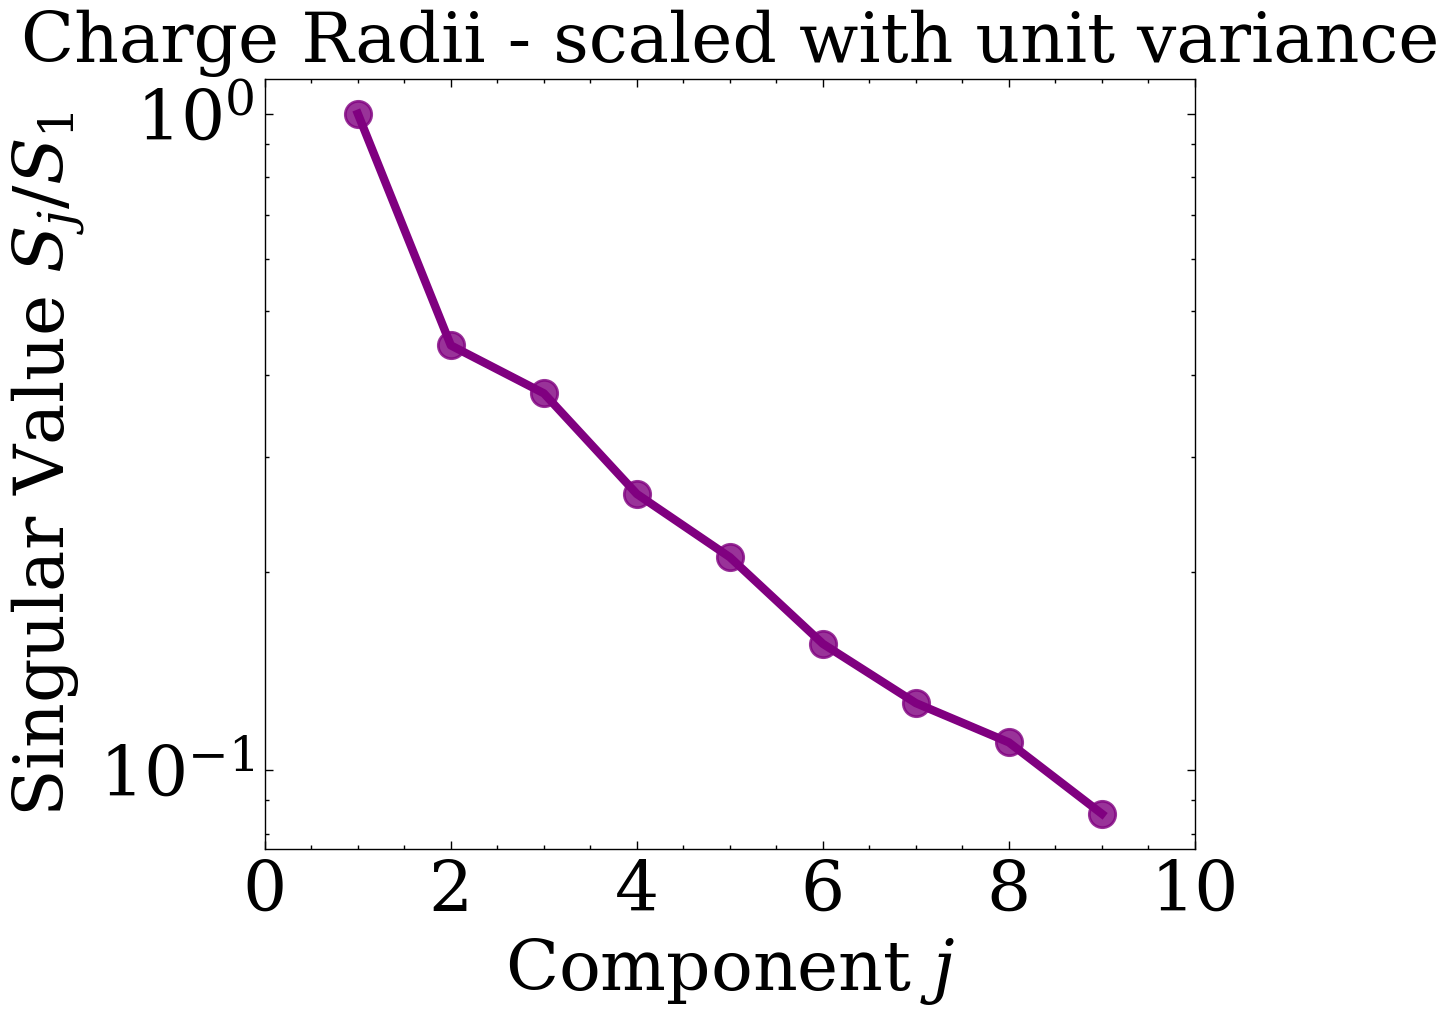

In [27]:
U, S, Vt = np.linalg.svd(model_predictions_radius_train_processed)

print(S)

plt.rc("xtick", labelsize = 25)
plt.rc("ytick", labelsize = 25)
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize = (6,5), dpi = 200)

ax.scatter(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", alpha = 0.8, s = 90, marker = 'o')
ax.plot(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", linewidth = 3)

ax.set_xticks([0,2,4,6,8,10])
plt.xlabel("Component $j$", fontsize = 25)
plt.ylabel("Singular Value $S_j/S_1$", fontsize = 25)
plt.yscale("log")
plt.title('Charge Radii - scaled with unit variance', fontsize = 25)
# plt.savefig('Plots/Radii data/Singular values decays/Singular Values - Radius Calibration - Scaled with unit variance.png')
plt.show()

In [28]:
# models_PC_dict = {}
# models_PC_dict_train = {}
# models_PC_dict_validation = {}
# models_PC_dict_test = {}

# for components_kept in range(1,len(S)):
#     U_hat = np.array([U.T[i] for i in range(components_kept)]).T
#     S_hat = S[:components_kept]
#     Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
#     models_PC_dict[f'{}']

SyntaxError: f-string: empty expression not allowed (2669587191.py, line 10)

In [28]:
components_kept = 9
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized=np.array([Vt[i] for i in range(components_kept)])
# Vt_hat = np.array([Vt[i] for i in range(components_kept)])

In [29]:
models_PC_radius = models_PC_output(Vt_hat, model_predictions_radius, predictions_mean_radius, models_output_radius)
models_PC_radius_train = models_PC_output(Vt_hat, model_predictions_radius_train, predictions_mean_radius_train, models_output_radius_train)
models_PC_radius_validation = models_PC_output(Vt_hat, model_predictions_radius_validation, predictions_mean_radius_validation, models_output_radius_validation)
models_PC_radius_test = models_PC_output(Vt_hat, model_predictions_radius_test, predictions_mean_radius_test, models_output_radius_test)

In [30]:
y = models_output_radius_train['truth'] - predictions_mean_radius_train
X_train = U_hat.copy()

X_T_X_train = X_train.T.dot(X_train)
X_T_X_train_inv = np.linalg.inv(X_T_X_train)
super_beta = X_T_X_train_inv.dot(X_train.T).dot(y)

# super_beta_full = np.insert(super_beta,0,1)
# naive_supermodel_train = models_PC_radius_train.values.dot(super_beta_full)

model_weights = np.dot(super_beta, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
model_weights = np.array(model_weights)
naive_supermodel_train = model_predictions_radius_train.dot(model_weights)

residuals_train_2PCs = naive_supermodel_train - models_output_radius_train['truth']
sigma_train_2PCs = np.sqrt(np.sum(residuals_train_2PCs **2)/ len(residuals_train_2PCs))
sigma_train_2PCs

0.13292320359291435

In [31]:
super_params_train = super_params(model_predictions_radius_train, models_output_radius_train['truth'])
supermodel_radius_train = super_params_train.dot(model_predictions_radius_train.T)
supermodel_radius_validation = super_params_train.dot(model_predictions_radius_validation.T)
supermodel_radius_test = super_params_train.dot(model_predictions_radius_test.T)
supermodel_radius_full = super_params_train.dot(model_predictions_radius.T)

supermodel_residuals_radius_train=supermodel_radius_train-models_output_radius_train['truth'].tolist()
supermodel_residuals_radius_validation= supermodel_radius_validation-models_output_radius_validation['truth'].tolist()
supermodel_residuals_radius_test = supermodel_radius_test-models_output_radius_test['truth'].tolist()
supermodel_residuals_radius_full = supermodel_radius_full-models_output_radius['truth'].tolist()

supermodel_sigma_radius_train=np.sqrt(np.sum(supermodel_residuals_radius_train**2) / len(supermodel_residuals_radius_train) )
supermodel_sigma_radius_validation=np.sqrt(np.sum(supermodel_residuals_radius_validation**2) / len(supermodel_residuals_radius_validation) )
supermodel_sigma_radius_test=np.sqrt(np.sum(supermodel_residuals_radius_test**2) / len(supermodel_residuals_radius_test) )
supermodel_sigma_radius_full=np.sqrt(np.sum(supermodel_residuals_radius_full**2) / len(supermodel_residuals_radius_full) )

In [32]:
if centering_data:
    s_radius_validation=[np.linalg.norm(np.array(models_output_radius_validation["truth"].tolist())-predictions_mean_radius_validation)/np.sqrt(len(predictions_mean_radius_validation))]
    s_radius_test=[np.linalg.norm(np.array(models_output_radius_test["truth"].tolist())-predictions_mean_radius_test)/np.sqrt(len(predictions_mean_radius_test))]
    s_radius_train=[np.linalg.norm(np.array(models_output_radius_train["truth"].tolist())-predictions_mean_radius_train)/np.sqrt(len(predictions_mean_radius_train))]
    s_radius_all=[np.linalg.norm(np.array(models_output_radius["truth"].tolist())-predictions_mean_radius)/np.sqrt(len(predictions_mean_radius))]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator(i, model_predictions_radius_train, predictions_mean_radius_train, models_output_radius_train, models_output_radius_list, model_predictions_radius_list, U, S, Vt)
        s_radius_all.append(res[0])
        s_radius_train.append(res[1])
        s_radius_validation.append(res[2])
        
        s_radius_test.append(res[3])

[0.11601885 0.13385252 0.11113574 0.12805697 0.08403806 0.06211054
 0.07570773 0.08996028 0.09911358 0.10000573]
0.17232488778400604
[0.13328906 0.14857416 0.13588326 0.11710836 0.07322821 0.08024858
 0.09665459 0.06515094 0.06399109 0.08587174]
0.17190363055986757
[ 0.34392729 -0.11533387  0.08663521  0.31967588  0.26610034  0.01413435
  0.11456083 -0.07053871 -0.01632433  0.05716301]
0.15483725388001074
[ 0.29863387  0.07476556 -0.05468322  0.2763606   0.48884319  0.02090677
  0.14145623 -0.23317328  0.0822567  -0.09536642]
0.14798117704539648
[ 0.44169616  0.05386612 -0.15309611  0.31402587  0.31715089  0.16223088
  0.10318021 -0.2602329   0.23088231 -0.20970343]
0.14479754513277066
[ 0.65611539  0.04228661 -0.07576557  0.09163901  0.4220676   0.04420682
  0.02541324 -0.02625629  0.23144645 -0.41115326]
0.1413962557019832
[ 0.43910118  0.04871117 -0.00132918  0.39004852  0.4607356   0.17811578
 -0.04218152  0.17413674  0.09587126 -0.74320955]
0.1380228265849404
[ 0.43252245  0.04172

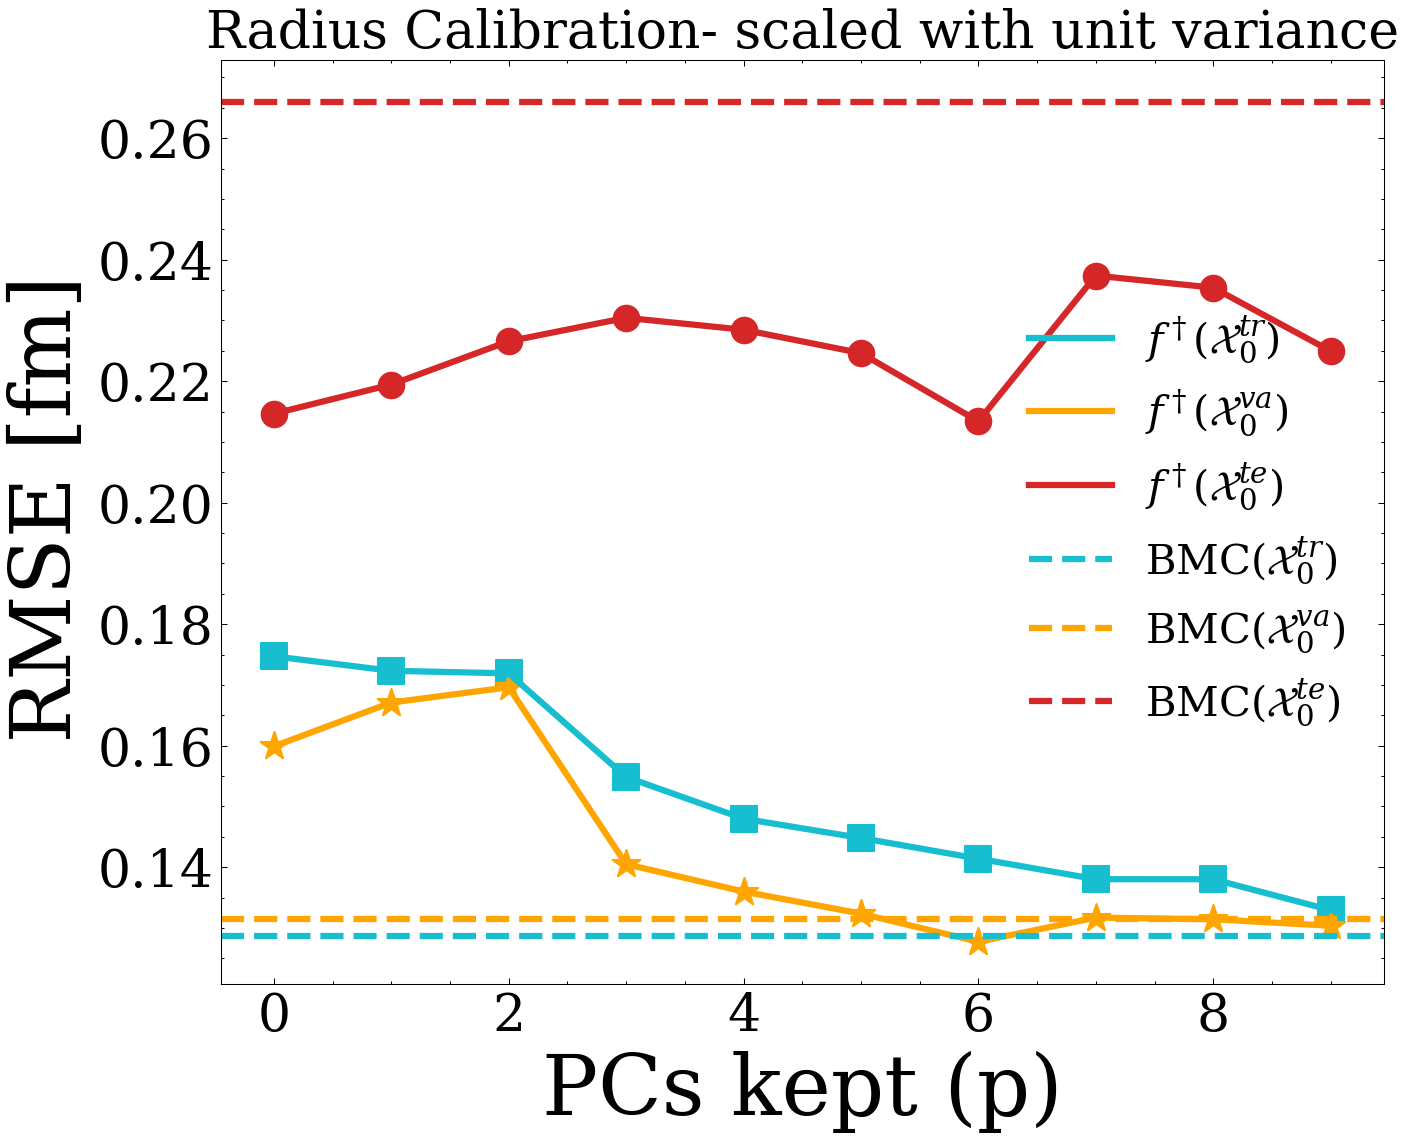

In [33]:
plt.rc("xtick", labelsize=25)
plt.rc("ytick", labelsize=25)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_radius_train)), s_radius_train,color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_radius_train)), s_radius_train,color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_radius_validation)), s_radius_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_radius_validation)), s_radius_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_radius_test)), s_radius_test,color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_radius_test)), s_radius_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

ax.axhline(y=supermodel_sigma_radius_train,color=color_train,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)
ax.axhline(y=supermodel_sigma_radius_validation,color=color_validation,label="BMC$(\mathcal{X}_0^{va})$",linestyle='dashed',linewidth=3)
ax.axhline(y=supermodel_sigma_radius_test,color=color_test,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'PCs kept (p)',fontsize=40)
ax.set_ylabel(r' RMSE [fm]',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=20)
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.title('Radius Calibration- scaled with unit variance', fontsize = 25)
# plt.savefig('Plots/Radii data/RMSE decays/Radii RMSE decays - Radius Calibration - Scaled with unit variance.png')
# plt.legend(fontsize=30)
plt.show()

+ Some very first result shows that there not much of a difference in our analysis when we impose some scaling scheme in the radii dataset. It is surprising that singular values decays is identical to when we perfrom on our original dataset.
+ The graph of RMSE is even more confusing as in the extrapolation part, the testing dataset seems to even worsen for when we use different number of PCs.

+ Let's try to first perform PCA on a smaller regions of radius dataset. We want to see how our analysis do locally, and if our performance seems to be more promising, we can start thinking of some local PCA directions

In [34]:
# We want to take a smaller regions of nuclei to see if PCA decomposition gives any better performance
filtered_NZ_radius_local = filtered_NZ_radius[(filtered_NZ_radius[:,0] <= 40) & (filtered_NZ_radius[:,1] <= 40)]
filtered_NZ_df_radius_local = pd.DataFrame({'N' : filtered_NZ_radius_local.T[0], 'Z' : filtered_NZ_radius_local.T[1]})

In [35]:
stable_coordinates_radius_df_local = pd.merge(filtered_NZ_df_radius_local, stable_coordinates_df, how = 'inner')
stable_coordinates_radius_local = stable_coordinates_radius_df_local.values

In [36]:
selected_models_data_sets_radius_local = selected_models_data_sets_radius.copy().loc[(selected_models_data_sets_radius['N'] <= 40) &\
                                                        (selected_models_data_sets_radius['Z'] <= 40)]
selected_models_data_sets_radius_local

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1
0,8,8,2.6991,2.729,2.691,2.747,2.735,2.794203,2.824011,2.795792,2.817382,2.793546,2.790816
1,10,8,2.7726,2.733,2.704,2.749,2.728,2.793734,2.825080,2.799074,2.807857,2.785015,2.781329
2,8,10,2.9714,2.956,2.912,2.945,2.955,2.956188,2.987489,2.964309,2.991813,2.966094,2.973445
3,10,10,3.0055,2.986,2.942,2.975,2.973,2.942506,2.973045,2.951974,2.974810,2.935663,2.967315
4,12,10,2.9525,2.960,2.949,2.978,2.941,2.964141,2.972133,2.976913,2.981346,2.925008,2.968485
5,14,10,2.9007,2.918,2.934,2.948,2.907,2.944405,2.978754,2.959388,2.952878,2.928863,2.937187
6,16,10,2.9251,2.927,2.940,2.935,2.900,2.963817,2.997073,2.977890,2.971168,2.949838,2.951236
7,18,10,2.9642,2.974,2.954,2.977,2.949,2.999775,3.029061,3.010574,3.005784,2.991987,2.990783
8,12,12,3.0570,3.079,3.035,3.112,3.053,3.095257,3.115114,3.117943,3.117073,3.056209,3.104676
9,14,12,3.0337,2.986,3.089,3.079,3.019,3.056680,3.089794,3.087691,3.074414,3.044779,3.059319


In [37]:
#Traditional way with stable coordinates to seperate our data points for nuclei - radius data sets

distance1=1.75
distance2=2.5

training_set_radius_local, validation_set_radius_local, test_set_radius_local, train_coordinates_radius_local, validation_coordinates_radius_local,test_coordinates_radius_local=separate_points_distance_allSets(filtered_NZ_radius_local, stable_coordinates_radius_local, distance1,distance2)

In [632]:
#Traditional way with stable coordinates to seperate our data points for nuclei - mass data sets

distance1=2
distance2=3

training_set_mass, validation_set_mass, test_set_mass, train_coordinates_mass, validation_coordinates_mass,test_coordinates_mass=separate_points_distance_allSets(filtered_NZ_mass, stable_coordinates, distance1,distance2)

In [38]:
#Extract models output of different categories (mass and radius) and classify them into 4 regions: all,train, validation, test
models_output_radius_list_local = models_output_extraction(selected_models_data_sets_radius_local, train_coordinates_radius_local, validation_coordinates_radius_local, test_coordinates_radius_local)
[models_output_radius_local, models_output_radius_train_local, models_output_radius_validation_local, models_output_radius_test_local] = models_output_radius_list_local

model_predictions_radius_local=models_output_radius_local[key_list].values
model_predictions_radius_train_local=models_output_radius_train_local[key_list].values
model_predictions_radius_validation_local=models_output_radius_validation_local[key_list].values
model_predictions_radius_test_local=models_output_radius_test_local[key_list].values
model_predictions_radius_list_local = [model_predictions_radius_local, model_predictions_radius_train_local, model_predictions_radius_validation_local, model_predictions_radius_test_local]

predictions_mean_radius_local= np.mean(model_predictions_radius_local, axis=1)
predictions_mean_radius_train_local= np.mean(model_predictions_radius_train_local, axis=1)
predictions_mean_radius_validation_local= np.mean(model_predictions_radius_validation_local, axis=1)
predictions_mean_radius_test_local= np.mean(model_predictions_radius_test_local, axis=1)

model_predictions_radius_train_processed_local = model_predictions_radius_train_local - predictions_mean_radius_train_local[:,None]

In [39]:
models_output_radius_local

,N,Z,A,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,truth
0,8,8,16,2.729,2.691,2.747,2.735,2.794203,2.824011,2.795792,2.817382,2.793546,2.790816,2.6991
1,10,8,18,2.733,2.704,2.749,2.728,2.793734,2.825080,2.799074,2.807857,2.785015,2.781329,2.7726
2,8,10,18,2.956,2.912,2.945,2.955,2.956188,2.987489,2.964309,2.991813,2.966094,2.973445,2.9714
3,10,10,20,2.986,2.942,2.975,2.973,2.942506,2.973045,2.951974,2.974810,2.935663,2.967315,3.0055
4,12,10,22,2.960,2.949,2.978,2.941,2.964141,2.972133,2.976913,2.981346,2.925008,2.968485,2.9525
5,14,10,24,2.918,2.934,2.948,2.907,2.944405,2.978754,2.959388,2.952878,2.928863,2.937187,2.9007
6,16,10,26,2.927,2.940,2.935,2.900,2.963817,2.997073,2.977890,2.971168,2.949838,2.951236,2.9251
7,18,10,28,2.974,2.954,2.977,2.949,2.999775,3.029061,3.010574,3.005784,2.991987,2.990783,2.9642
8,12,12,24,3.079,3.035,3.112,3.053,3.095257,3.115114,3.117943,3.117073,3.056209,3.104676,3.0570
9,14,12,26,2.986,3.089,3.079,3.019,3.056680,3.089794,3.087691,3.074414,3.044779,3.059319,3.0337


[4.13722415e-01 1.69385791e-01 1.14067318e-01 9.56946327e-02
 8.01268928e-02 5.03566878e-02 3.57876240e-02 3.03991869e-02
 2.31844180e-02 6.04832843e-15]


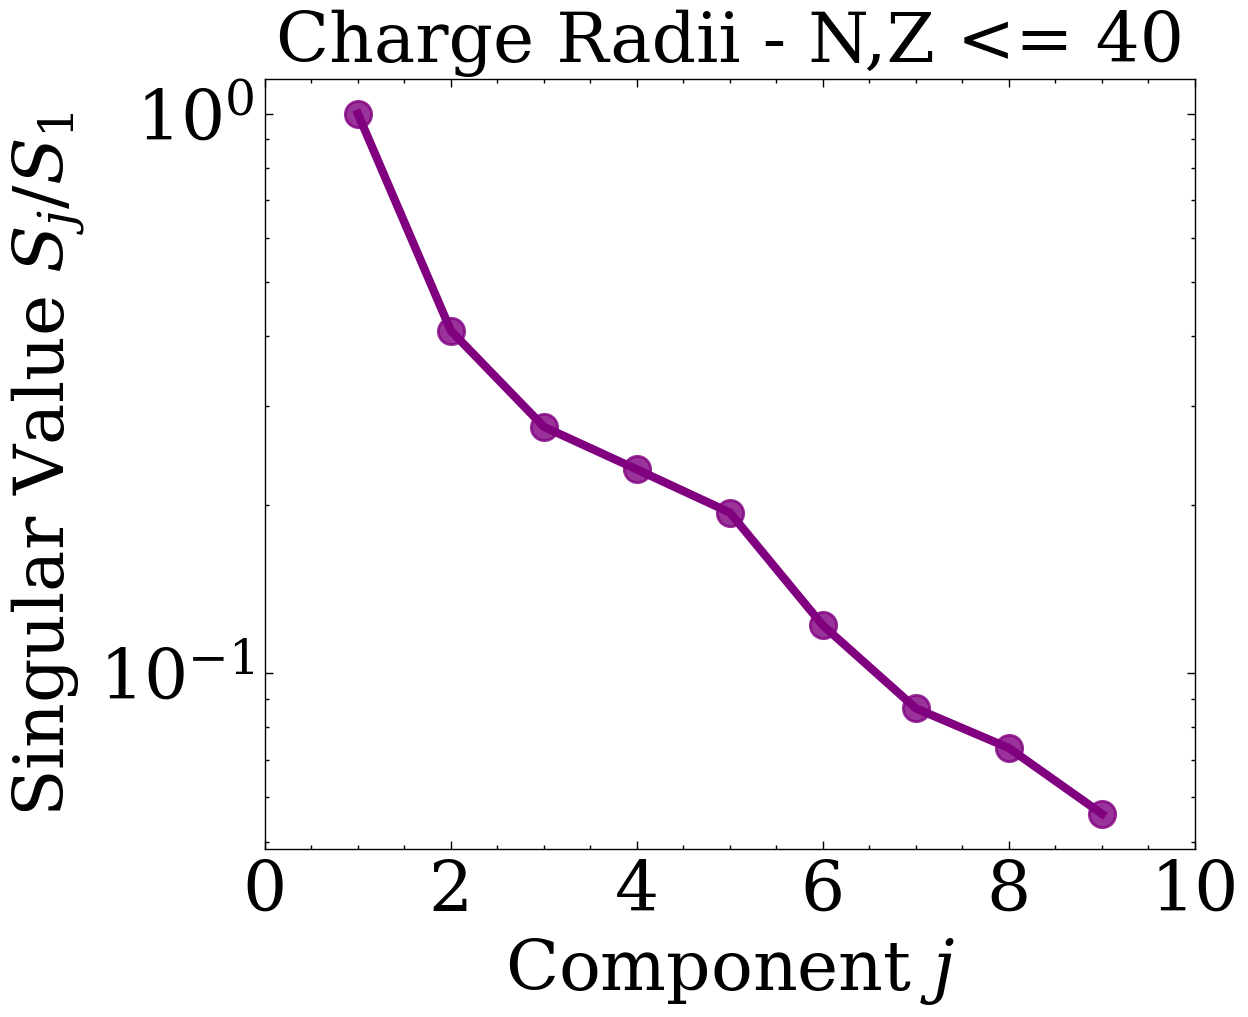

In [40]:
U_local, S_local, Vt_local = np.linalg.svd(model_predictions_radius_train_processed_local)

print(S_local)

plt.rc("xtick", labelsize = 25)
plt.rc("ytick", labelsize = 25)
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize = (6,5), dpi = 200)

ax.scatter(np.arange(1, S_local.size ), S_local[:-1]/S_local[0], color = "purple", alpha = 0.8, s = 90, marker = 'o')
ax.plot(np.arange(1, S_local.size ), S_local[:-1]/S_local[0], color = "purple", linewidth = 3)

ax.set_xticks([0,2,4,6,8,10])
plt.xlabel("Component $j$", fontsize = 25)
plt.ylabel("Singular Value $S_j/S_1$", fontsize = 25)
plt.yscale("log")
plt.title('Charge Radii - N,Z <= 40', fontsize = 25)
# plt.savefig('Plots/Radii data/Singular values decays/Singular Values - Radius Calibration - N,Z smaller than 40 local PCA.png')
plt.show()

In [41]:
U_hat_local, S_hat_local, Vt_hat_local = USVt_hat_extraction(U_local,S_local,Vt_local, components_kept)

In [42]:
models_PC_radius_local = models_PC_output(Vt_hat_local, model_predictions_radius_local, predictions_mean_radius_local, models_output_radius_local)
models_PC_radius_train_local = models_PC_output(Vt_hat_local, model_predictions_radius_train_local, predictions_mean_radius_train_local, models_output_radius_train_local)
models_PC_radius_validation_local = models_PC_output(Vt_hat_local, model_predictions_radius_validation_local, predictions_mean_radius_validation_local, models_output_radius_validation_local)
models_PC_radius_test_local = models_PC_output(Vt_hat_local, model_predictions_radius_test_local, predictions_mean_radius_test_local, models_output_radius_test_local)

In [43]:
y_local = models_output_radius_train_local['truth'] - predictions_mean_radius_train_local
X_train_local = U_hat_local.copy()

X_T_X_train_local = X_train_local.T.dot(X_train_local)
X_T_X_train_inv_local = np.linalg.inv(X_T_X_train_local)
super_beta_local = X_T_X_train_inv_local.dot(X_train_local.T).dot(y_local)

In [44]:
def residuals_calculator(model_weights, model_predictions_list, models_output_list):
    #Note that we for every models output list we put all nuclei first, and then train, validation, test region
    supermodel_full = model_weights.dot(model_predictions_list[0].T)
    supermodel_train = model_weights.dot(model_predictions_list[1].T)
    supermodel_validation = model_weights.dot(model_predictions_list[2].T)
    supermodel_test = model_weights.dot(model_predictions_list[3].T)

    supermodel_residuals_full = supermodel_full-models_output_list[0]['truth'].tolist()
    supermodel_residuals_train=supermodel_train-models_output_list[1]['truth'].tolist()
    supermodel_residuals_validation= supermodel_validation-models_output_list[2]['truth'].tolist()
    supermodel_residuals_test = supermodel_test-models_output_list[3]['truth'].tolist()

    return supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test

In [45]:
super_params_train_local = super_params(model_predictions_radius_train_local, models_output_radius_train_local['truth'])
[supermodel_residuals_radius_full_local, supermodel_residuals_radius_train_local, supermodel_residuals_radius_validation_local, supermodel_residuals_radius_test_local] = \
residuals_calculator(super_params_train_local, model_predictions_radius_list_local, models_output_radius_list_local)

supermodel_sigma_radius_train_local=np.sqrt(np.sum(supermodel_residuals_radius_train_local**2) / len(supermodel_residuals_radius_train_local) )
supermodel_sigma_radius_validation_local=np.sqrt(np.sum(supermodel_residuals_radius_validation_local**2) / len(supermodel_residuals_radius_validation_local) )
supermodel_sigma_radius_test_local=np.sqrt(np.sum(supermodel_residuals_radius_test_local**2) / len(supermodel_residuals_radius_test_local) )
supermodel_sigma_radius_full_local=np.sqrt(np.sum(supermodel_residuals_radius_full_local**2) / len(supermodel_residuals_radius_full_local) )

In [46]:
if centering_data:
    s_radius_validation_local=[np.linalg.norm(np.array(models_output_radius_validation_local["truth"].tolist())-predictions_mean_radius_validation_local)/np.sqrt(len(predictions_mean_radius_validation_local))]
    s_radius_test_local=[np.linalg.norm(np.array(models_output_radius_test_local["truth"].tolist())-predictions_mean_radius_test_local)/np.sqrt(len(predictions_mean_radius_test_local))]
    s_radius_train_local=[np.linalg.norm(np.array(models_output_radius_train_local["truth"].tolist())-predictions_mean_radius_train_local)/np.sqrt(len(predictions_mean_radius_train_local))]
    s_radius_all_local=[np.linalg.norm(np.array(models_output_radius_local["truth"].tolist())-predictions_mean_radius_local)/np.sqrt(len(predictions_mean_radius_local))]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator(i, model_predictions_radius_train_local, predictions_mean_radius_train_local, models_output_radius_train_local, models_output_radius_list_local, model_predictions_radius_list_local, U, S, Vt)
        s_radius_all_local.append(res[0])
        s_radius_train_local.append(res[1])
        s_radius_validation_local.append(res[2])
        
        s_radius_test_local.append(res[3])

[0.12402296 0.15076755 0.11669991 0.14207615 0.07606238 0.04317838
 0.06356965 0.08494375 0.09867067 0.10000859]
0.02176580210494947
[0.13439762 0.15927185 0.13176497 0.13485699 0.06966835 0.05499367
 0.07688759 0.06982218 0.0770392  0.09129757]
0.021747934020552882
[ 0.36802121 -0.06120403  0.14951637  0.2755519   0.22586189  0.06549899
  0.16523485 -0.1190962  -0.09470077  0.0253158 ]
0.01957827257156143
[ 0.35839364 -0.00148397  0.10031606  0.26529666  0.30746027  0.0668496
  0.17581361 -0.1798554  -0.06399907 -0.02879138]
0.01945593739012772
[ 0.61709662 -0.02730533 -0.0679955   0.33115881 -0.03582958  0.32391657
  0.09841229 -0.21682458  0.20832934 -0.23095864]
0.017685461177558672
[ 0.33130061 -0.03534623 -0.14814271  0.71917486 -0.31916204  0.60885443
  0.27237107 -0.66202297  0.1414319   0.09154107]
0.01676406667354686
[ 0.24589135 -0.01181423 -0.1050761   0.84722105 -0.2585012   0.66745779
  0.21007537 -0.49858698  0.08050879 -0.17717584]
0.01662736008178371
[ 0.29849638  0.13

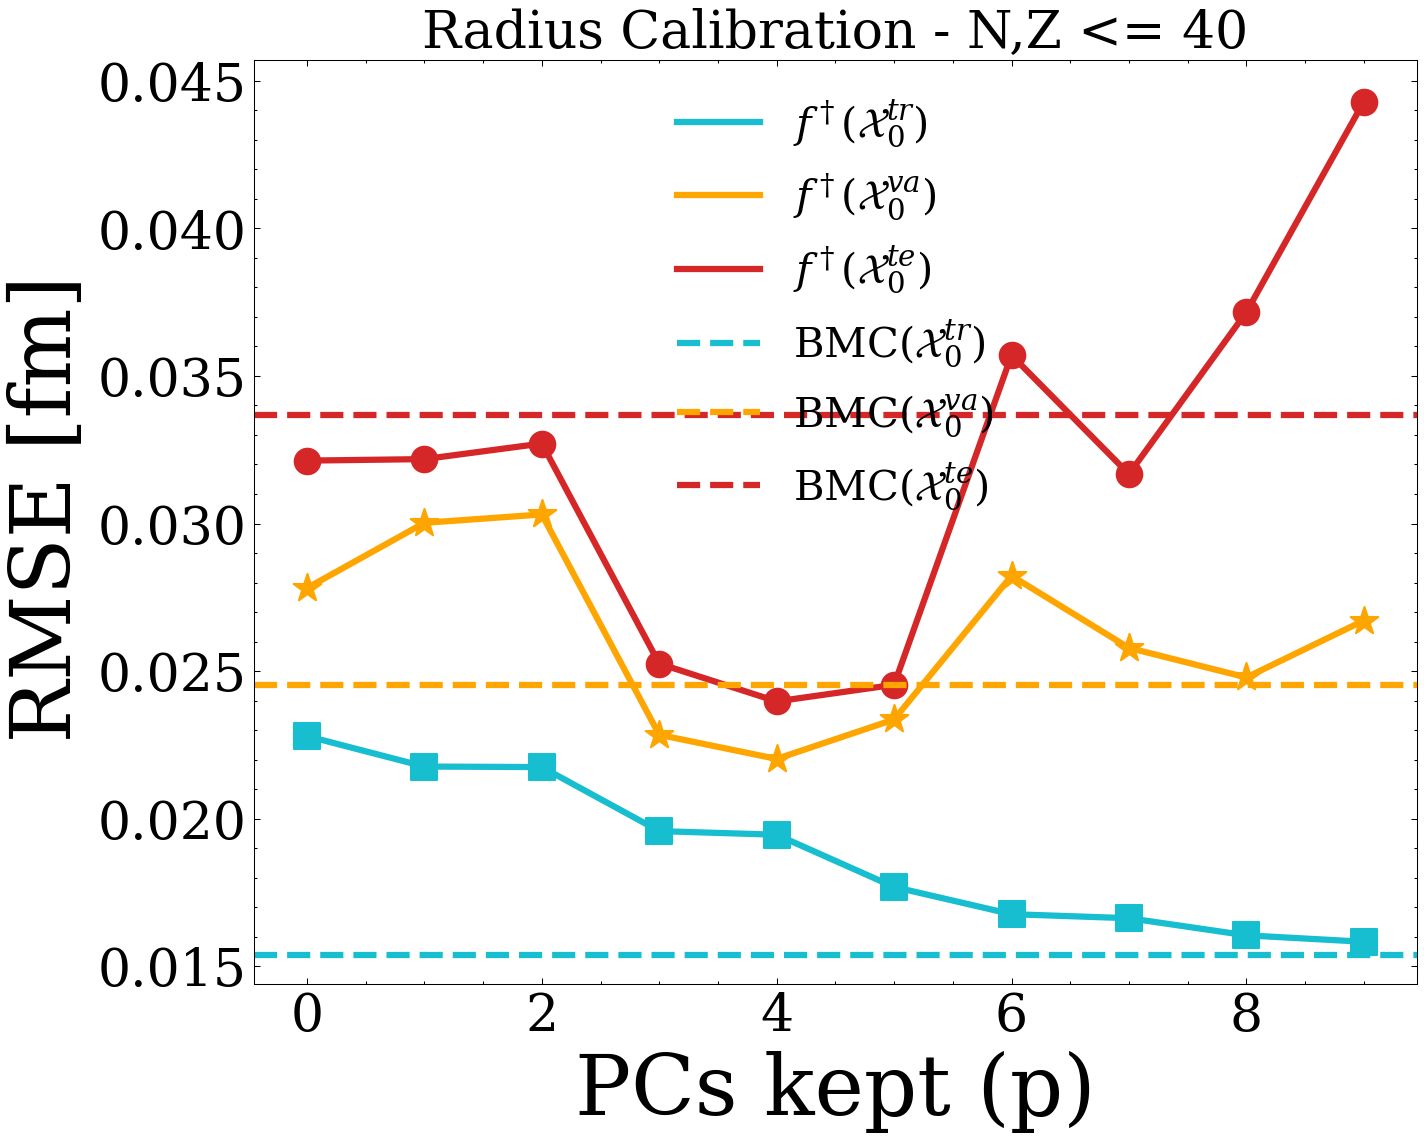

In [47]:
plt.rc("xtick", labelsize=25)
plt.rc("ytick", labelsize=25)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_radius_train_local)), s_radius_train_local,color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_radius_train_local)), s_radius_train_local,color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_radius_validation_local)), s_radius_validation_local,color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_radius_validation_local)), s_radius_validation_local,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_radius_test_local)), s_radius_test_local,color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_radius_test_local)), s_radius_test_local,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

ax.axhline(y=supermodel_sigma_radius_train_local,color=color_train,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)
ax.axhline(y=supermodel_sigma_radius_validation_local,color=color_validation,label="BMC$(\mathcal{X}_0^{va})$",linestyle='dashed',linewidth=3)
ax.axhline(y=supermodel_sigma_radius_test_local,color=color_test,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'PCs kept (p)',fontsize=40)
ax.set_ylabel(r' RMSE [fm]',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=20)
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.title('Radius Calibration - N,Z <= 40', fontsize = 25)
# plt.savefig('Plots/Radii data/RMSE decays/Radii RMSE decays - Radius Calibration - N,Z smaller than 40 local PCA.png')
# plt.legend(fontsize=30)
plt.show()

+ What we are observing right now with the model calibration for radii is that there are some abrupt, non-smooth changes in the PCs. This could be because our models do not share a lot of correlation in the radii data, and because of that PCA wants to detect variance among the models' space, which are not present from the beginning. To make sure that we do not make any mistakes in our code, Witek wants to see if we would see the same behaviour occur when we perform PCA decomposition on a smooth model space. 

In [48]:
#Extract models output of different categories (mass and radius) and classify them into 4 regions: all,train, validation, test
models_output_mass_list = models_output_extraction(selected_models_data_sets_mass, train_coordinates_mass, validation_coordinates_mass, test_coordinates_mass)
models_output_radius_list = models_output_extraction(selected_models_data_sets_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)

In [49]:
#Separate them for further use
[models_output_mass, models_output_mass_train, models_output_mass_validation, models_output_mass_test] = models_output_mass_list
[models_output_radius, models_output_radius_train, models_output_radius_validation, models_output_radius_test] = models_output_radius_list

In [50]:
filtered_models_output_mass_list_50 = filtered_models_output_extraction(50, models_output_mass, train_coordinates_mass, validation_coordinates_mass, test_coordinates_mass)
filtered_models_output_radius_list_20 = filtered_models_output_extraction(20, models_output_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)

filtered_models_output_mass_stable_50 = filtered_models_output_stable_extraction(50, models_output_mass, stable_coordinates)
filtered_models_output_radius_stable_20 = filtered_models_output_stable_extraction(20, models_output_radius, stable_coordinates_radius)

[filtered_models_output_mass_50, filtered_models_output_mass_train_50, filtered_models_output_mass_validation_50, filtered_models_output_mass_test_50] = filtered_models_output_mass_list_50
[filtered_models_output_radius_50, filtered_models_output_radius_train_20, filtered_models_output_radius_validation_20, filtered_models_output_radius_test_20] = filtered_models_output_radius_list_20

model_predictions_mass=models_output_mass[key_list].values
model_predictions_mass_train=models_output_mass_train[key_list].values
model_predictions_mass_validation=models_output_mass_validation[key_list].values
model_predictions_mass_test=models_output_mass_test[key_list].values
model_predictions_mass_list = [model_predictions_mass, model_predictions_mass_train, model_predictions_mass_validation, model_predictions_mass_test]

model_predictions_radius=models_output_radius[key_list].values
model_predictions_radius_train=models_output_radius_train[key_list].values
model_predictions_radius_validation=models_output_radius_validation[key_list].values
model_predictions_radius_test=models_output_radius_test[key_list].values
model_predictions_radius_list = [model_predictions_radius, model_predictions_radius_train, model_predictions_radius_validation, model_predictions_radius_test]

model_predictions_combined = np.vstack((model_predictions_mass, model_predictions_radius))
model_predictions_combined_train = np.vstack((model_predictions_mass_train, model_predictions_radius_train))
model_predictions_combined_validation = np.vstack((model_predictions_mass_validation, model_predictions_radius_validation))
model_predictions_combined_test = np.vstack((model_predictions_mass_test, model_predictions_radius_test))
model_predictions_combined_list = [model_predictions_combined, model_predictions_combined_train, model_predictions_combined_validation, model_predictions_combined_test]

predictions_mean_mass= np.mean(model_predictions_mass, axis=1)
predictions_mean_mass_train= np.mean(model_predictions_mass_train, axis=1)
predictions_mean_mass_validation= np.mean(model_predictions_mass_validation, axis=1)
predictions_mean_mass_test= np.mean(model_predictions_mass_test, axis=1)

predictions_mean_radius= np.mean(model_predictions_radius, axis=1)
predictions_mean_radius_train= np.mean(model_predictions_radius_train, axis=1)
predictions_mean_radius_validation= np.mean(model_predictions_radius_validation, axis=1)
predictions_mean_radius_test= np.mean(model_predictions_radius_test, axis=1)

predictions_mean_combined= np.mean(model_predictions_combined, axis=1)
predictions_mean_combined_train= np.mean(model_predictions_combined_train, axis=1)
predictions_mean_combined_validation= np.mean(model_predictions_combined_validation, axis=1)
predictions_mean_combined_test= np.mean(model_predictions_combined_test, axis=1)

predictions_mean_radius_df = pd.DataFrame({'N' : filtered_NZ_radius.T[0], 'Z' : filtered_NZ_radius.T[1], 'PC_0' : predictions_mean_radius})

In [51]:
models_output_radius

,N,Z,A,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,truth
0,8,8,16,2.729,2.691,2.747,2.735,2.794203,2.824011,2.795792,2.817382,2.793546,2.790816,2.6991
1,10,8,18,2.733,2.704,2.749,2.728,2.793734,2.825080,2.799074,2.807857,2.785015,2.781329,2.7726
2,8,10,18,2.956,2.912,2.945,2.955,2.956188,2.987489,2.964309,2.991813,2.966094,2.973445,2.9714
3,10,10,20,2.986,2.942,2.975,2.973,2.942506,2.973045,2.951974,2.974810,2.935663,2.967315,3.0055
4,12,10,22,2.960,2.949,2.978,2.941,2.964141,2.972133,2.976913,2.981346,2.925008,2.968485,2.9525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,150,94,244,5.933,5.920,5.930,5.942,5.910061,5.918577,5.915247,5.902641,5.908618,5.923415,5.8948
341,146,96,242,5.935,5.921,5.933,5.936,5.919476,5.928108,5.924384,5.908823,5.911968,5.928126,5.8285
342,148,96,244,5.948,5.938,5.947,5.951,5.929864,5.939063,5.934703,5.920200,5.923912,5.940104,5.8429
343,150,96,246,5.958,5.945,5.956,5.964,5.939141,5.949234,5.944656,5.930929,5.935161,5.951470,5.8562


In [442]:
def random_radii_function(A, N, Z, a_1, a_2, a_3, a_4, a_5, a_6, a_7, a_8, a_9):
    return 1.2 * (A**a_1) + a_2 * np.cos(A) + a_3 * np.exp(A/150) + a_4 * N + a_5 * Z + a_6 * np.exp(-np.abs(N-20)/10) + \
    a_7 * np.exp(-np.abs(Z - 28)/5) + a_8 * np.exp(-np.abs(Z-50)/5) + a_9 * np.exp(-np.abs(N - 82)/5)

In [512]:
A_radii = models_output_radius['A'].values
Z_radii = models_output_radius['N'].values
N_radii = models_output_radius['Z'].values
model_1 = random_radii_function(A_radii, N_radii, Z_radii, 0, 0, 0, 0, 0, 4, 0, 0, 0)
model_2 = random_radii_function(A_radii, N_radii, Z_radii, 0, 0.15, 0, 0, 0, 0, 4, 0, 0)
model_3 = random_radii_function(A_radii, N_radii, Z_radii, 0, 0.3, 1, 0, 0, 0, 0, 4, 0)
model_4 = random_radii_function(A_radii, N_radii, Z_radii, 0.29, 0, 0, -0.02, 0.01, 0, 0, 0, 4)
model_5 = random_radii_function(A_radii, N_radii, Z_radii, 0, 0.025, 0.03, 0.015, 0.015, 0, 0, 3, 0)
model_6 = random_radii_function(A_radii, N_radii, Z_radii, 0, 0, 1, -0.02, 0.01, 0, 3, 0, 0)
model_7 = random_radii_function(A_radii, N_radii, Z_radii, 0, 0, 0.8, 0, 0, 2, 2, 0, 2)
model_8 = random_radii_function(A_radii, N_radii, Z_radii, 0.24, 0.2, 0, 0, 0, 2, 0, 2, 0)
model_9 = random_radii_function(A_radii, N_radii, Z_radii, 0.2, 0.02, 0.3, 0, 0, 0, 3, 0, 3)
model_10 = random_radii_function(A_radii, N_radii, Z_radii, 0.1, 0.04, 0.2, 0.01, 0.01, 0, 2, 2, 2)
fake_models = [model_1, model_2, model_3, model_4, model_5, model_6, model_7, model_8, model_9, model_10]

In [513]:
model_10

array([1.96469754, 2.08940079, 2.0711638 , 2.11930835, 2.12876681,
       2.26371432, 2.36957586, 2.43108153, 2.22312688, 2.30902625,
       2.28020251, 2.42025554, 2.4816518 , 2.53831277, 2.73504842,
       2.42110346, 2.44798436, 2.60029338, 2.8110938 , 2.97958384,
       3.32216128, 3.85724616, 4.49882521, 2.77855295, 3.02225709,
       3.40984035, 3.83137283, 4.52166273, 3.9695099 , 3.1099375 ,
       3.38396835, 3.85421168, 4.61679726, 3.94934821, 4.602405  ,
       3.95900185, 4.60629418, 4.05667504, 3.63355592, 4.05753537,
       3.62077362, 3.44635809, 3.3064165 , 3.46493624, 3.28049501,
       3.29440292, 3.33166638, 3.33169632, 3.29713175, 3.445385  ,
       3.65931393, 3.37212297, 3.50085892, 3.62134157, 3.9498491 ,
       4.44539201, 3.37054972, 3.37218959, 3.42761885, 3.46290852,
       3.68052318, 4.02149263, 4.40940646, 5.09764552, 4.51458792,
       4.03833275, 3.76032338, 3.65214371, 3.50039855, 3.38970122,
       3.5221229 , 3.75219948, 3.98553985, 4.4504616 , 5.18214

In [514]:
fake_model_name_list = ['model_1', 'model_2', 'model_3', 'model_4', 'model_5', 'model_6', 'model_7', 'model_8', 'model_9', 'model_10']

In [515]:
selected_fake_models_data_sets_radius = selected_models_data_sets_radius[['N' , 'Z' , 'truth']].copy()
for i in range(len(fake_model_name_list)):
    selected_fake_models_data_sets_radius[fake_model_name_list[i]] = fake_models[i] 
selected_fake_models_data_sets_radius

,N,Z,truth,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,model_10
0,8,8,2.6991,2.404777,1.129614,2.026165,2.601491,1.450110,2.287510,2.729071,2.745678,2.458885,1.964698
1,10,8,2.7726,2.404777,1.408342,2.526934,2.714665,1.521339,2.349468,2.759034,3.136424,2.572551,2.089401
2,8,10,2.9714,2.671518,1.372310,2.526491,2.654665,1.521007,2.262444,2.874389,3.269573,2.545527,2.071164
3,10,10,3.0055,2.671518,1.370507,2.466397,2.760752,1.545487,2.324602,2.904512,3.280842,2.617601,2.119308
4,12,10,2.9525,2.671518,1.213055,2.059981,2.860926,1.541241,2.400255,2.943659,3.056548,2.676400,2.128767
...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,150,94,5.8948,1.202445,1.275386,6.437661,5.892012,5.025171,5.906890,5.452171,4.590790,5.411230,5.738231
341,146,96,5.8285,1.202002,1.050710,5.920936,5.678293,4.955704,5.759515,5.338233,4.282143,5.265412,5.583317
342,148,96,5.8429,1.202002,1.275386,6.437661,5.712380,5.025171,5.846890,5.392133,4.590569,5.321507,5.678416
343,150,96,5.8562,1.202002,1.286547,6.528263,5.746386,5.059080,5.935170,5.446757,4.614254,5.349366,5.716746


In [516]:
models_output_radius_list_fake = models_output_extraction(selected_fake_models_data_sets_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
[models_output_radius_fake, models_output_radius_fake_train, models_output_radius_fake_validation, models_output_radius_fake_test] = models_output_radius_list_fake

model_predictions_radius_fake=models_output_radius_fake[fake_model_name_list].values
model_predictions_radius_fake_train=models_output_radius_fake_train[fake_model_name_list].values
model_predictions_radius_fake_validation=models_output_radius_fake_validation[fake_model_name_list].values
model_predictions_radius_fake_test=models_output_radius_fake_test[fake_model_name_list].values
model_predictions_radius_list_fake = [model_predictions_radius_fake, model_predictions_radius_fake_train, model_predictions_radius_fake_validation, model_predictions_radius_fake_test]

predictions_mean_radius_fake= np.mean(model_predictions_radius_fake, axis=1)
predictions_mean_radius_fake_train= np.mean(model_predictions_radius_fake_train, axis=1)
predictions_mean_radius_fake_validation= np.mean(model_predictions_radius_fake_validation, axis=1)
predictions_mean_radius_fake_test= np.mean(model_predictions_radius_fake_test, axis=1)

predictions_mean_radius_df = pd.DataFrame({'N' : filtered_NZ_radius.T[0], 'Z' : filtered_NZ_radius.T[1], 'PC_0' : predictions_mean_radius_fake})
model_predictions_radius_train_processed_fake = model_predictions_radius_fake_train - predictions_mean_radius_fake_train[:,None]

[4.52171800e+01 1.68420502e+01 1.20534694e+01 5.85457598e+00
 3.79598157e+00 3.48116867e+00 1.82478763e+00 2.71746109e-01
 1.62436385e-01 1.44894607e-14]


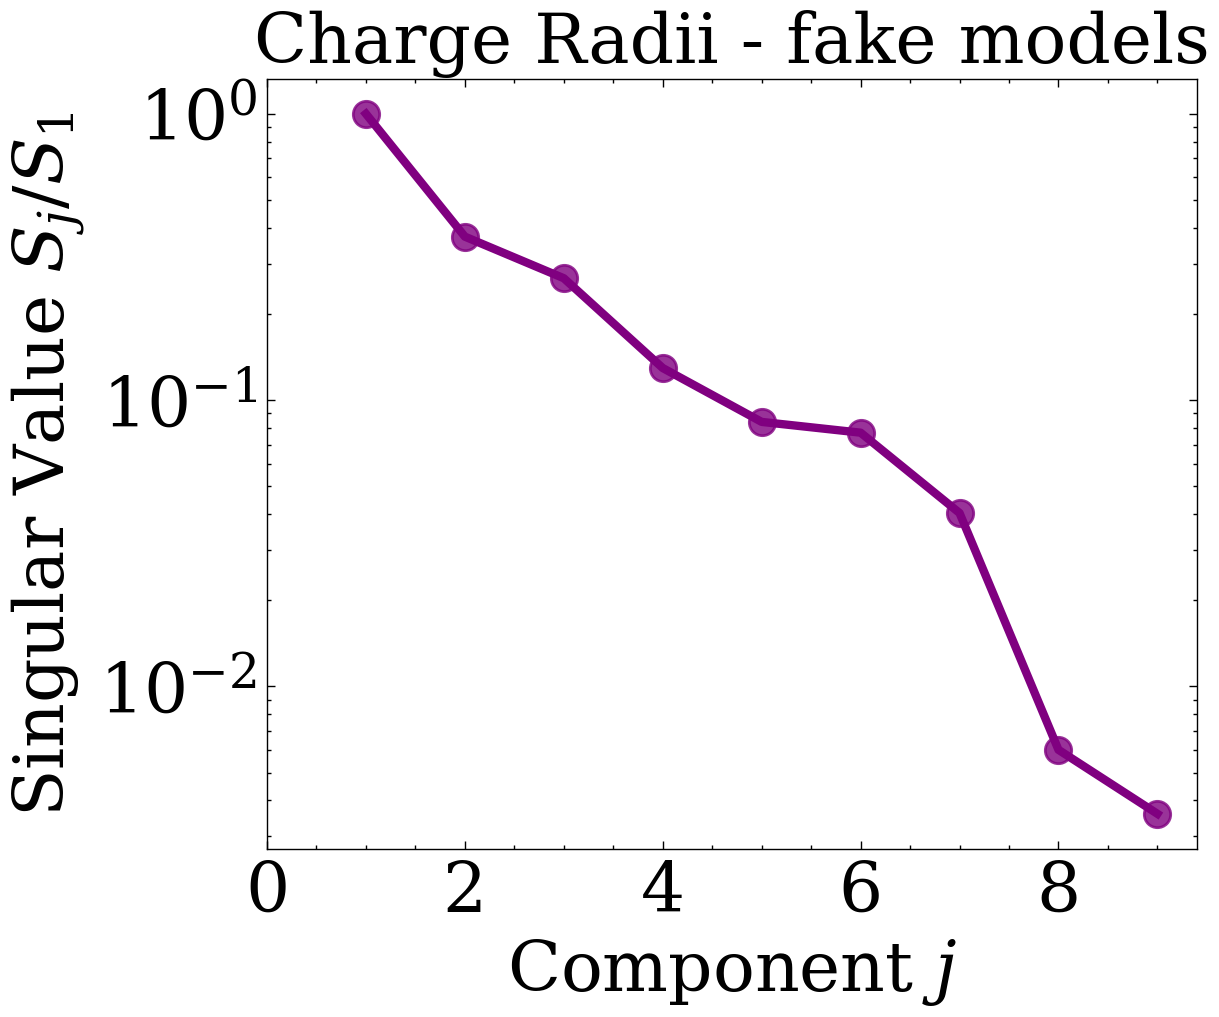

In [517]:
U_fake, S_fake, Vt_fake = np.linalg.svd(model_predictions_radius_train_processed_fake)

print(S_fake)

plt.rc("xtick", labelsize = 25)
plt.rc("ytick", labelsize = 25)
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize = (6,5), dpi = 200)

ax.scatter(np.arange(1, S_fake.size ), S_fake[:-1]/S_fake[0], color = "purple", alpha = 0.8, s = 90, marker = 'o')
ax.plot(np.arange(1, S_fake.size ), S_fake[:-1]/S_fake[0], color = "purple", linewidth = 3)

ax.set_xticks([0,2,4,6,8])
plt.xlabel("Component $j$", fontsize = 25)
plt.ylabel("Singular Value $S_j/S_1$", fontsize = 25)
plt.yscale("log")
plt.title('Charge Radii - fake models', fontsize = 25)
# plt.savefig('Plots/Radii data/Singular values decays/Singular Values - Radius Calibration - N,Z smaller than 40 local PCA.png')
plt.show()

In [518]:
components_kept = 9
U_hat_fake = np.array([U_fake.T[i] for i in range(components_kept)]).T
S_hat_fake = S_fake[:components_kept]
Vt_hat_fake = np.array([Vt_fake[i]/S_fake[i] for i in range(components_kept)])
Vt_hat_normalized_fake=np.array([Vt_fake[i] for i in range(components_kept)])
# Vt_hat = np.array([Vt[i] for i in range(components_kept)])

In [519]:
models_PC_radius_fake = models_PC_output(Vt_hat_fake, model_predictions_radius_fake, predictions_mean_radius_fake, models_output_radius_fake)
models_PC_radius_fake_train = models_PC_output(Vt_hat_fake, model_predictions_radius_fake_train, predictions_mean_radius_fake_train, models_output_radius_fake_train)
models_PC_radius_fake_validation = models_PC_output(Vt_hat_fake, model_predictions_radius_fake_validation, predictions_mean_radius_fake_validation, models_output_radius_fake_validation)
models_PC_radius_fake_test = models_PC_output(Vt_hat_fake, model_predictions_radius_fake_test, predictions_mean_radius_fake_test, models_output_radius_fake_test)

In [520]:
models_PC_radius_fake_train

,N,Z,A,PC_0,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9
0,8,8,16,2.179800,0.016693,0.053249,0.082011,0.062363,-0.063900,-0.070430,-0.099427,0.340420,0.075482
1,10,8,18,2.348293,0.018189,0.037237,0.094949,0.025405,-0.038119,-0.032759,-0.246981,0.264026,-0.008176
3,10,10,20,2.406153,0.016462,0.043418,0.111629,0.051349,-0.045649,-0.031853,-0.193648,0.212485,0.060737
4,12,10,22,2.355235,0.017555,0.062187,0.096444,0.080334,-0.040743,-0.069868,-0.068537,0.292194,0.004970
8,12,12,24,2.545415,0.015082,0.049940,0.131513,0.071845,-0.044052,-0.027809,-0.161202,0.143081,0.061170
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,126,82,208,5.206242,0.157865,0.126348,-0.124544,0.152348,0.000362,0.288058,-0.117055,0.006493,-0.093515
332,140,90,230,4.509136,0.117379,0.017184,-0.072674,-0.070343,-0.302212,-0.155004,-0.002126,0.095756,0.049152
333,142,90,232,4.665186,0.118307,-0.001863,-0.059763,-0.111668,-0.304175,-0.123063,-0.163374,0.025390,-0.008079
334,142,92,234,4.551290,0.114669,-0.003770,-0.060612,-0.116645,-0.338542,-0.169486,-0.083381,0.054791,0.100066


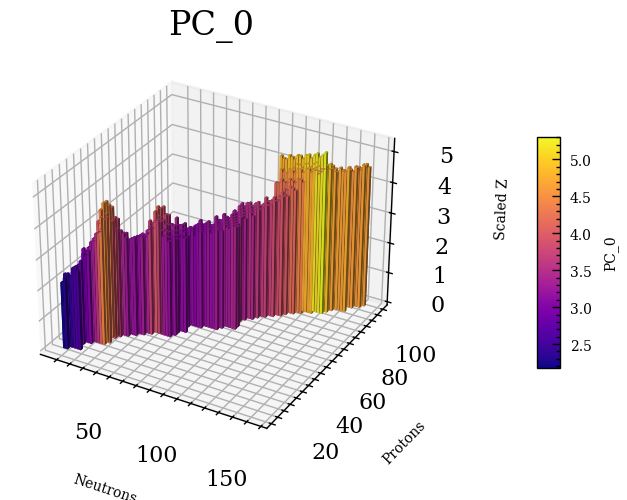

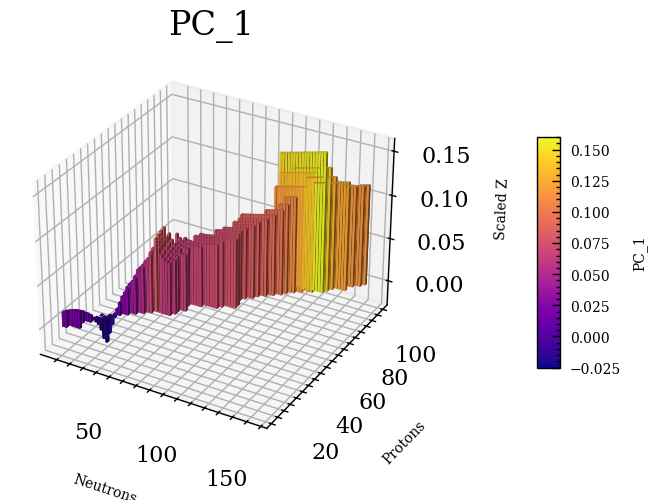

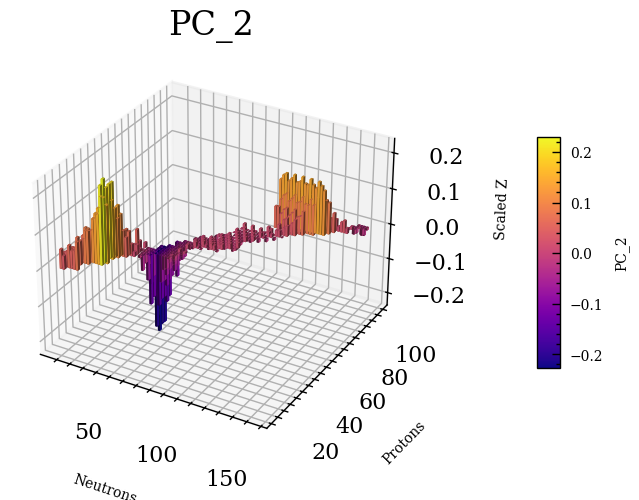

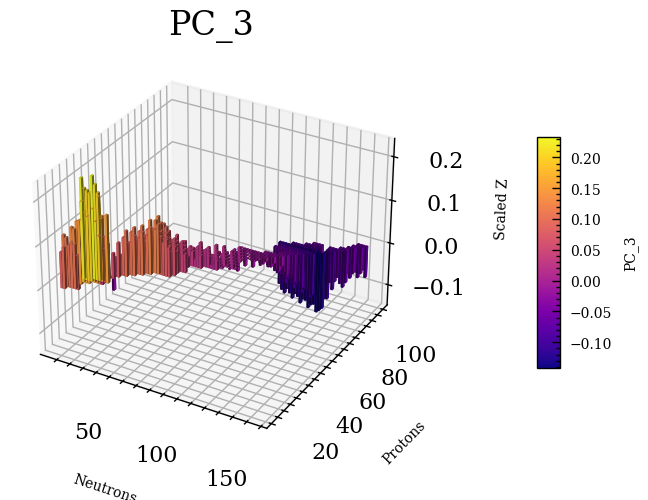

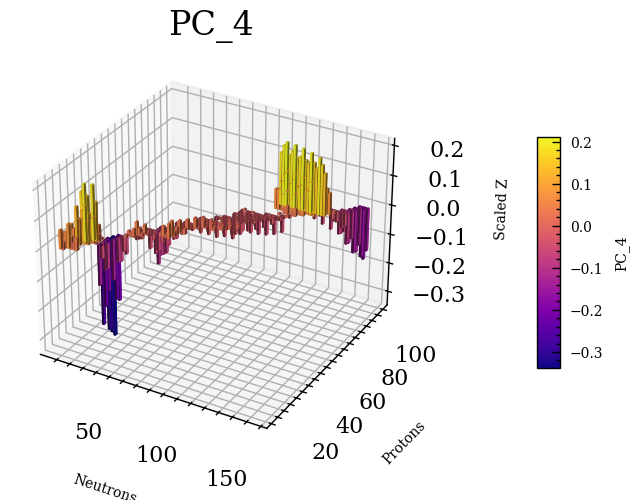

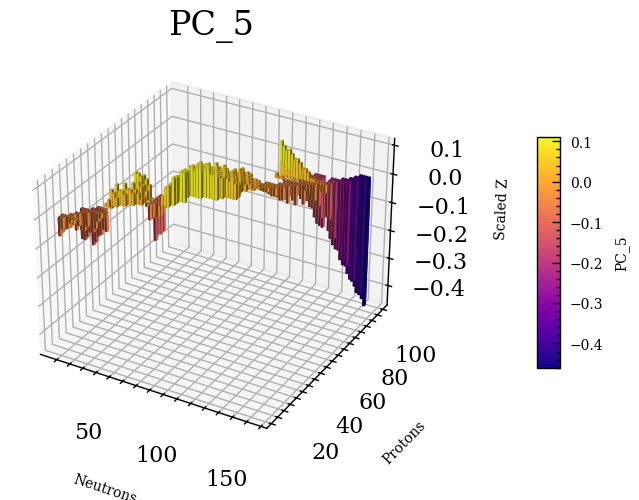

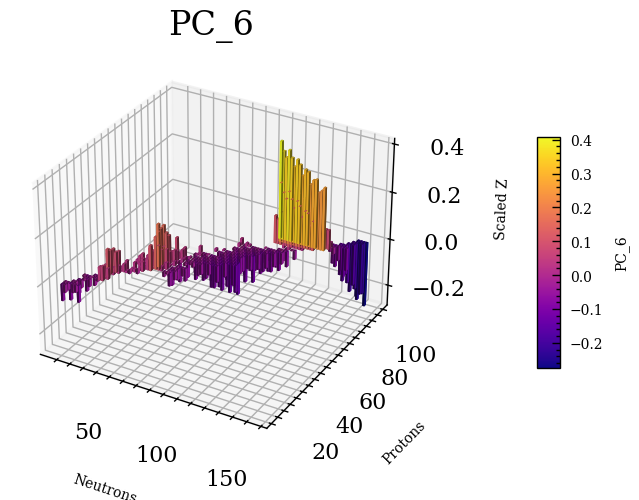

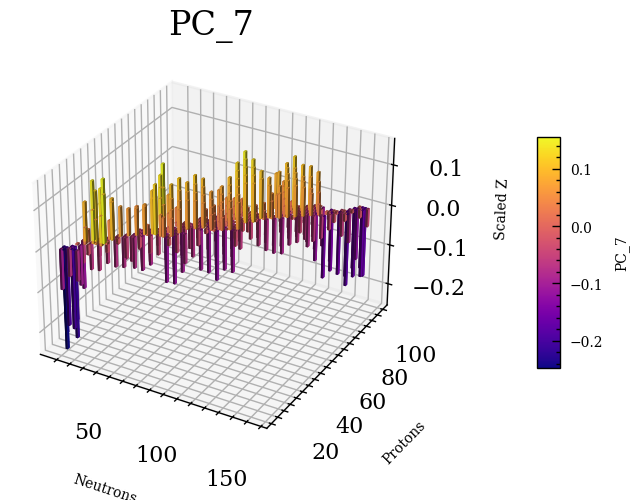

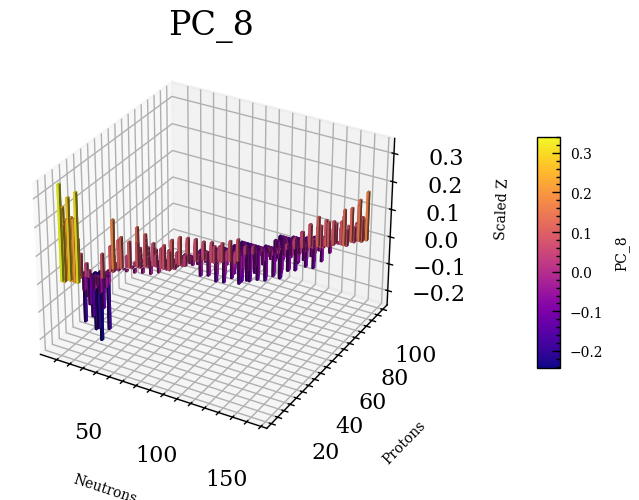

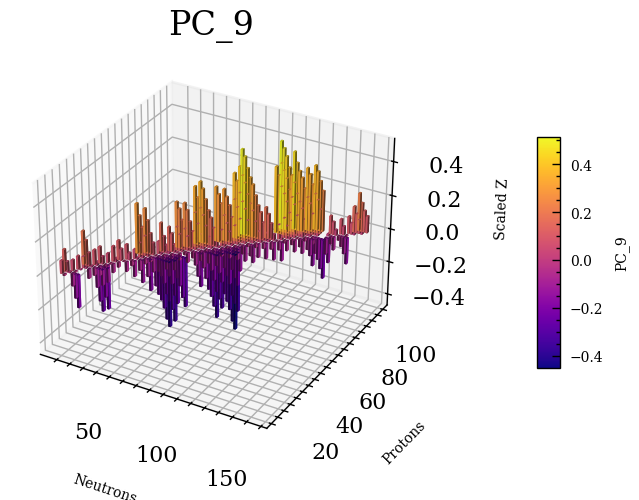

In [535]:
for PC in list(models_PC_radius_fake.keys())[3:]:
    plot_heatmap_3D(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], models_PC_radius_fake[PC], PC, elev=30,azim=-60)
    plt.savefig(f'Plots/Fake models analysis/Fourth 10 fake models/PCs 3D heat map - Radii/{PC}')

In [522]:
x = np.linspace(20,90,8)
Selected_elements_list = ['Ca', 'Zn', 'Zr', 'Sn', 'Nd', 'Yb', 'Hg', 'Th']

In [523]:
np.abs(models_PC_radius_fake['PC_2']).max()

0.23015442950195725

In [524]:
filtered_models_output_radius_dict_fake = filtered_models_output_dict_extraction(x, 'filtered_models_output_radius_list_' , models_output_radius_fake,\
                                    train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius, stable_coordinates_radius)
filtered_models_output_radius_dict_fake.keys()

dict_keys(['filtered_models_output_radius_list_20', 'filtered_models_output_radius_list_30', 'filtered_models_output_radius_list_40', 'filtered_models_output_radius_list_50', 'filtered_models_output_radius_list_60', 'filtered_models_output_radius_list_70', 'filtered_models_output_radius_list_80', 'filtered_models_output_radius_list_90'])

In [525]:
scaled_models_PC_radius_fake = models_PC_radius_fake.copy()
models_PC_radius_columns_fake = list(models_PC_radius_fake.columns)
for column in models_PC_radius_columns_fake[4:]:
    scaled_models_PC_radius_fake[column] = 2*scaled_models_PC_radius_fake[column]
scaled_models_PC_radius_fake

,N,Z,A,PC_0,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9
0,8,8,16,2.179800,0.033385,0.106499,0.164022,0.124726,-0.127800,-0.140861,-0.198854,0.680840,0.150965
1,10,8,18,2.348293,0.036377,0.074475,0.189899,0.050810,-0.076238,-0.065517,-0.493962,0.528053,-0.016352
2,8,10,18,2.376909,0.030236,0.076621,0.231049,0.092247,-0.117173,-0.044752,-0.429035,0.385724,0.254558
3,10,10,20,2.406153,0.032924,0.086835,0.223257,0.102698,-0.091299,-0.063707,-0.387297,0.424970,0.121474
4,12,10,22,2.355235,0.035110,0.124374,0.192887,0.160668,-0.081487,-0.139737,-0.137073,0.584388,0.009940
...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,150,94,244,4.693199,0.232026,-0.034001,-0.120808,-0.319038,-0.827193,-0.431266,-0.334482,0.180842,0.054984
341,146,96,242,4.503626,0.225501,-0.011684,-0.133279,-0.265002,-0.837524,-0.483071,-0.012139,0.241801,0.445757
342,148,96,244,4.648211,0.227404,-0.045694,-0.110759,-0.340513,-0.846410,-0.429052,-0.305545,0.123297,0.337127
343,150,96,246,4.688457,0.229246,-0.047355,-0.113629,-0.351504,-0.873050,-0.446645,-0.343568,0.153051,0.252930


In [526]:
scaled_filtered_models_PC_radius_dict_fake= filtered_models_output_dict_extraction(x, 'scaled_filtered_models_PC_radius_list_fake_' , scaled_models_PC_radius_fake,\
                                    train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius, stable_coordinates_radius)

In [527]:
for key in list(scaled_filtered_models_PC_radius_dict_fake.keys()):
    for dataframe in scaled_filtered_models_PC_radius_dict_fake[key]:
        dataframe.iloc[:,4:] = dataframe.iloc[:,4:] + np.mean(dataframe['PC_0'])

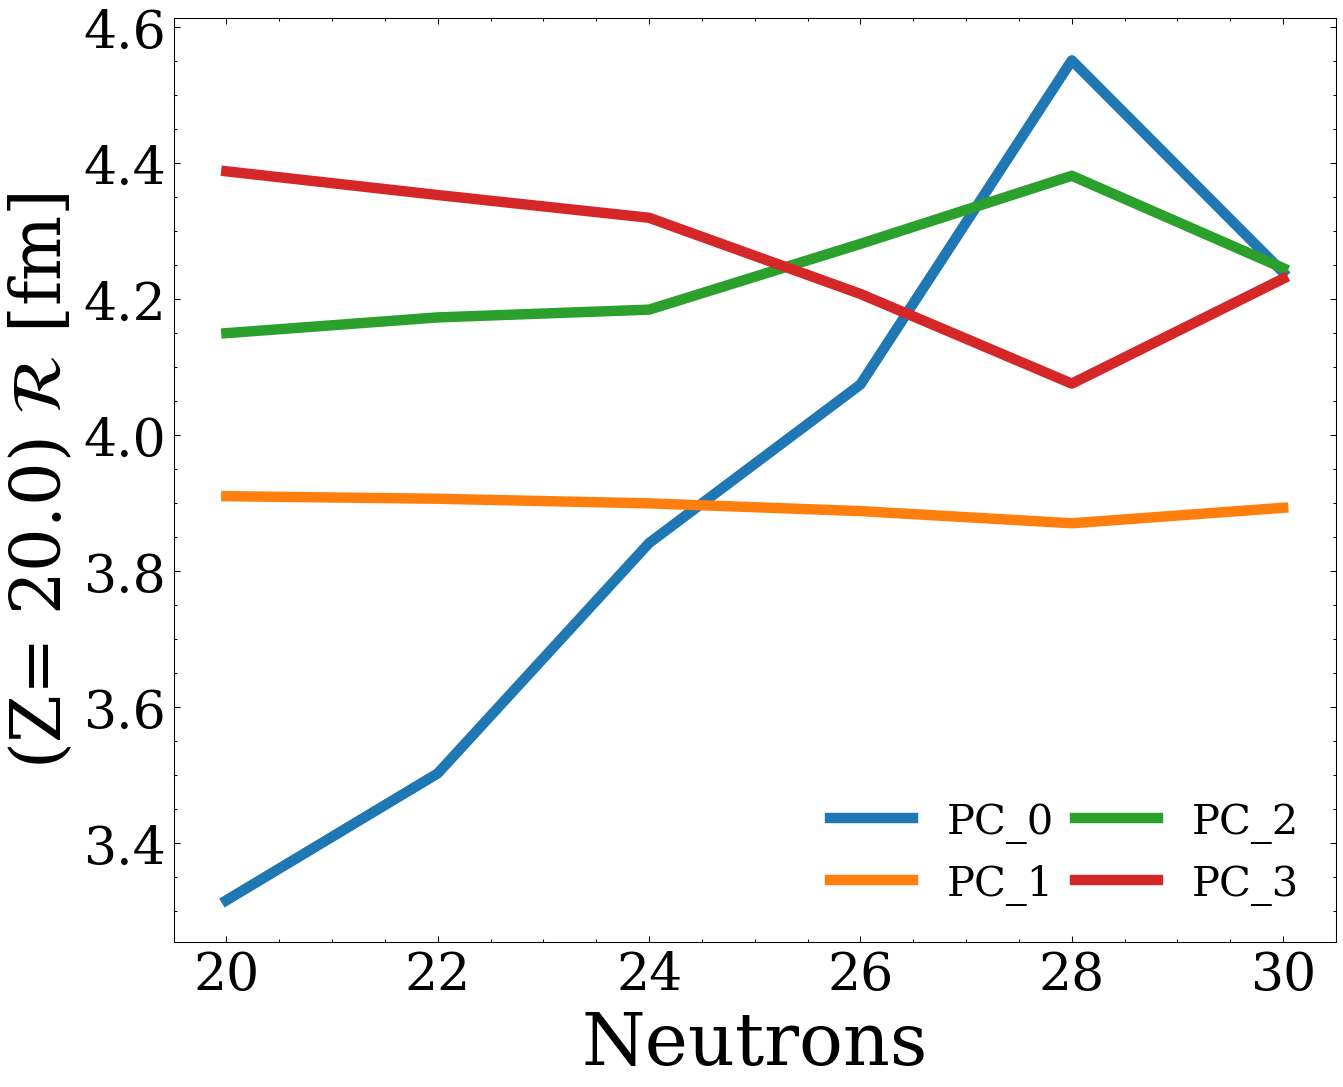

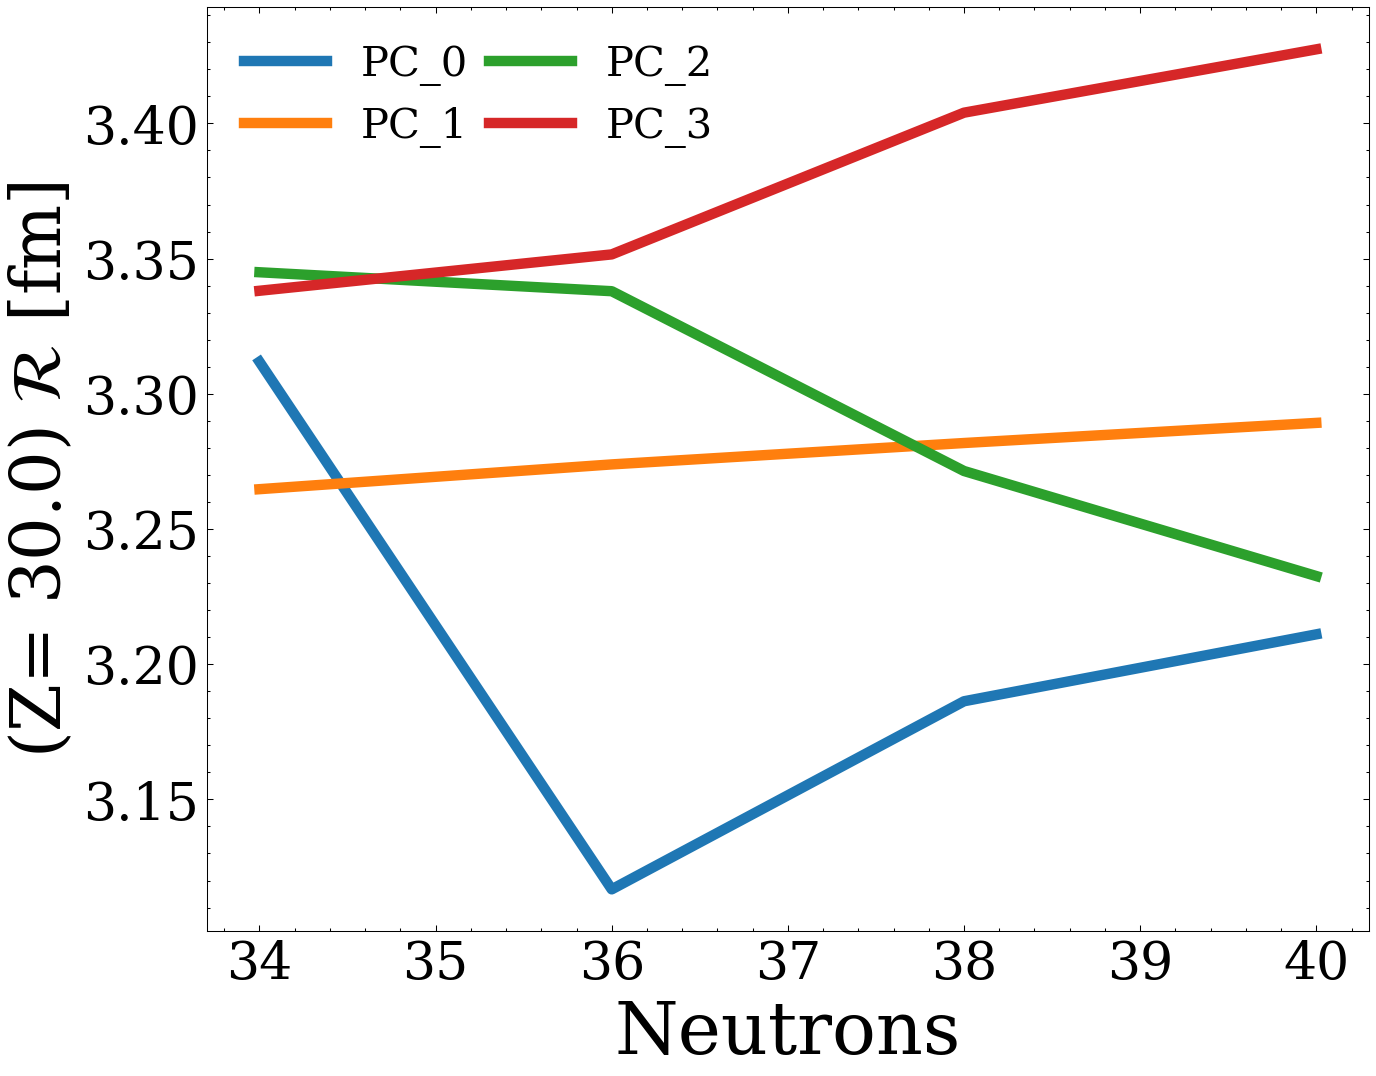

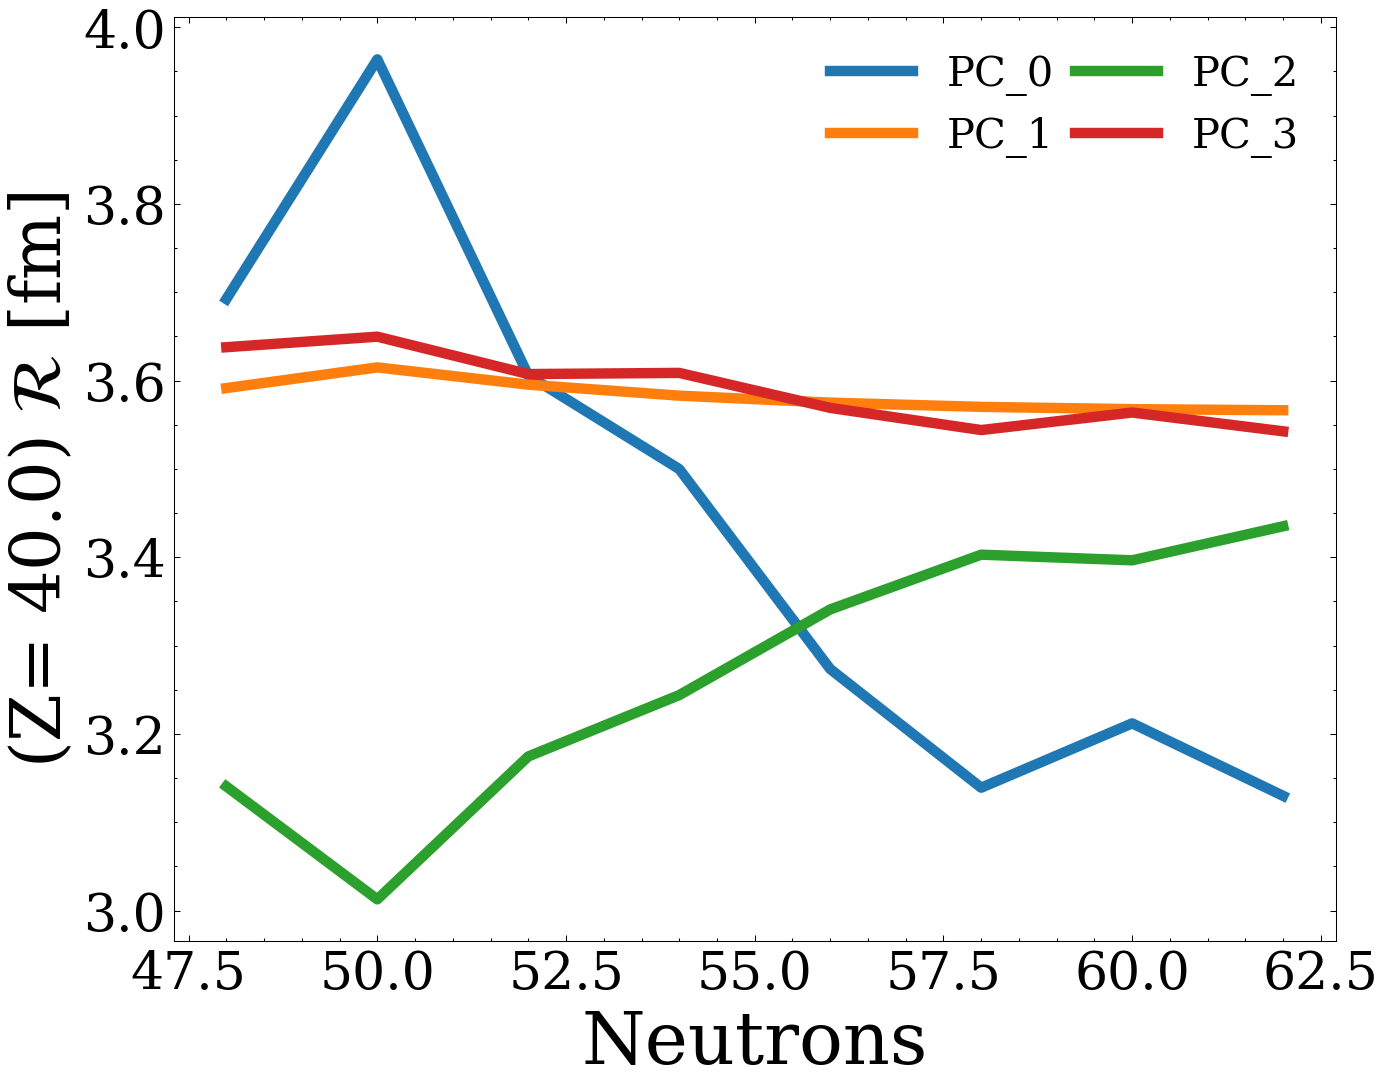

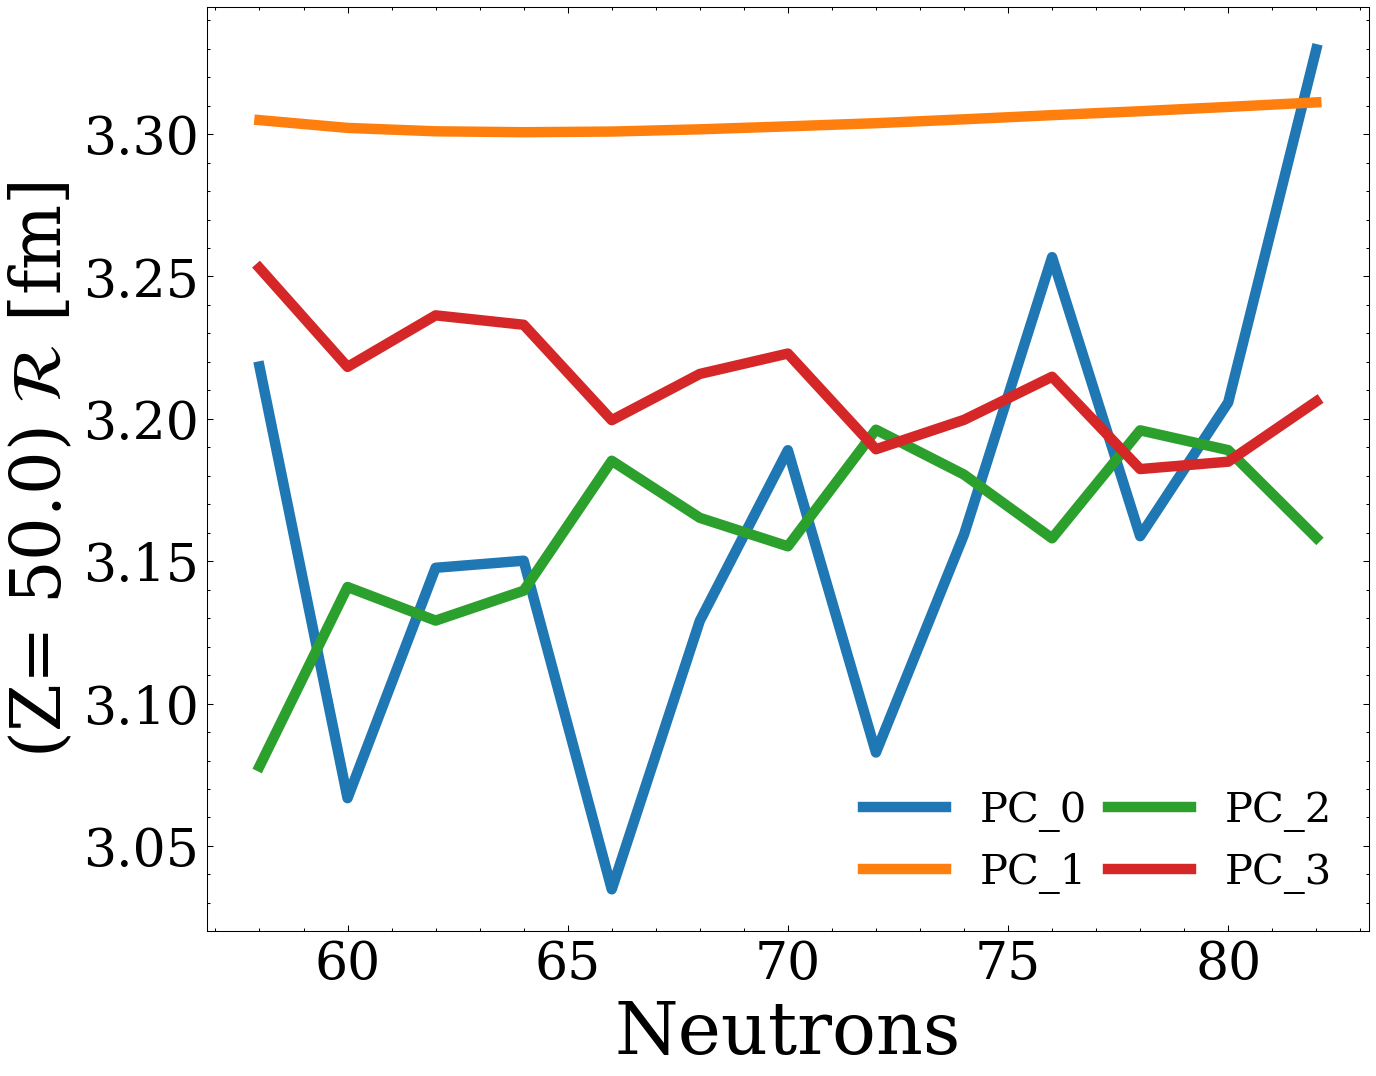

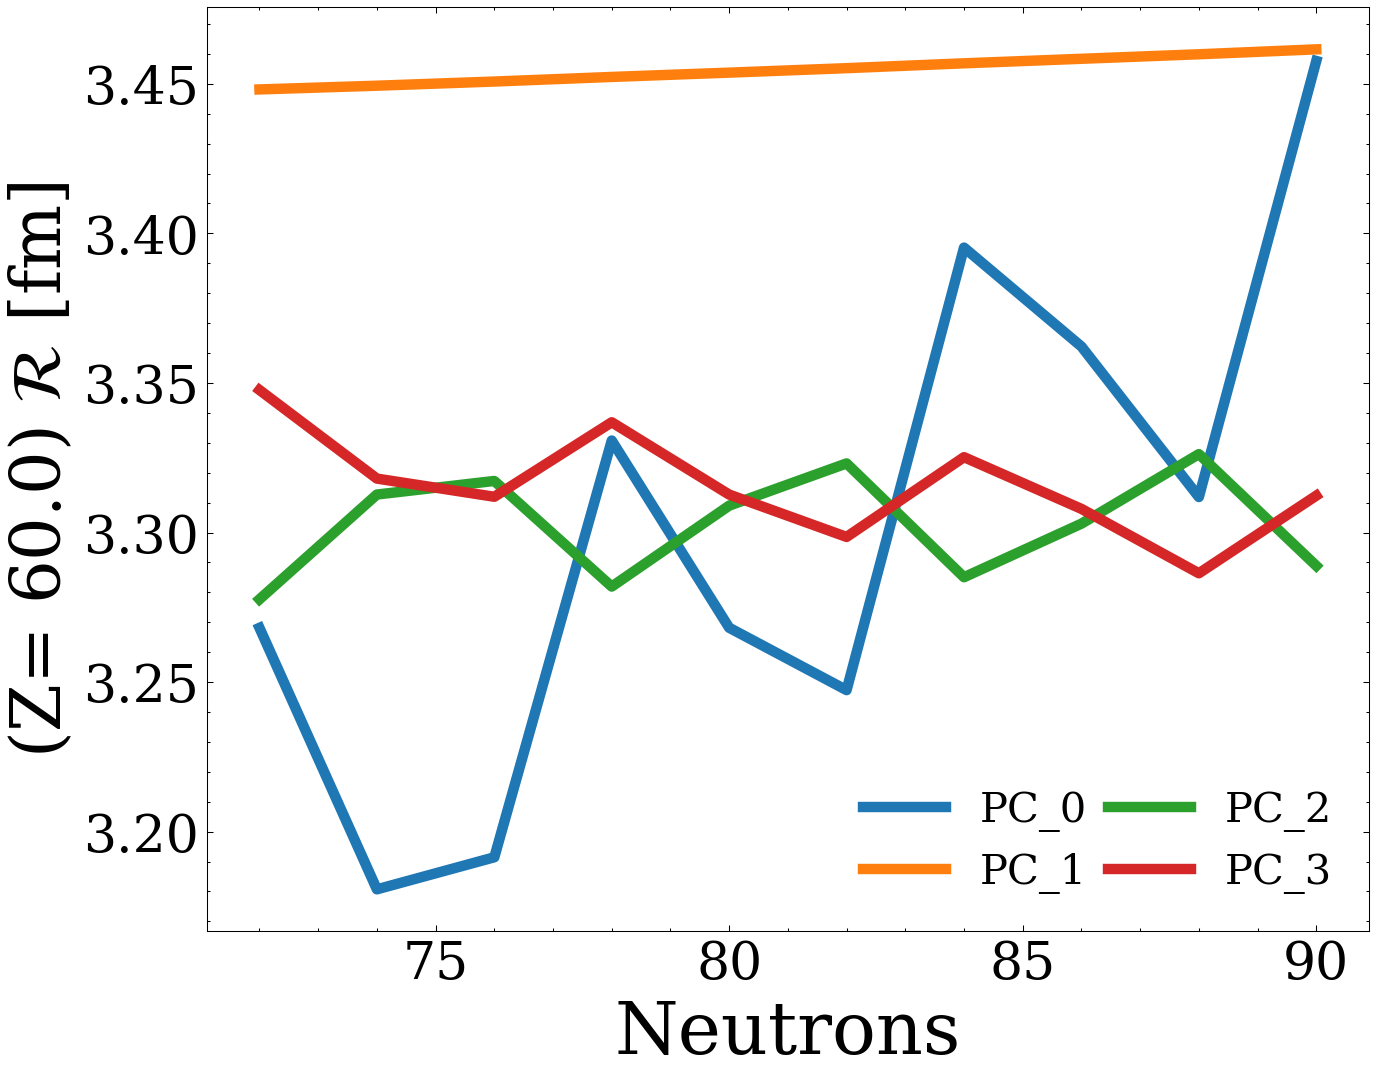

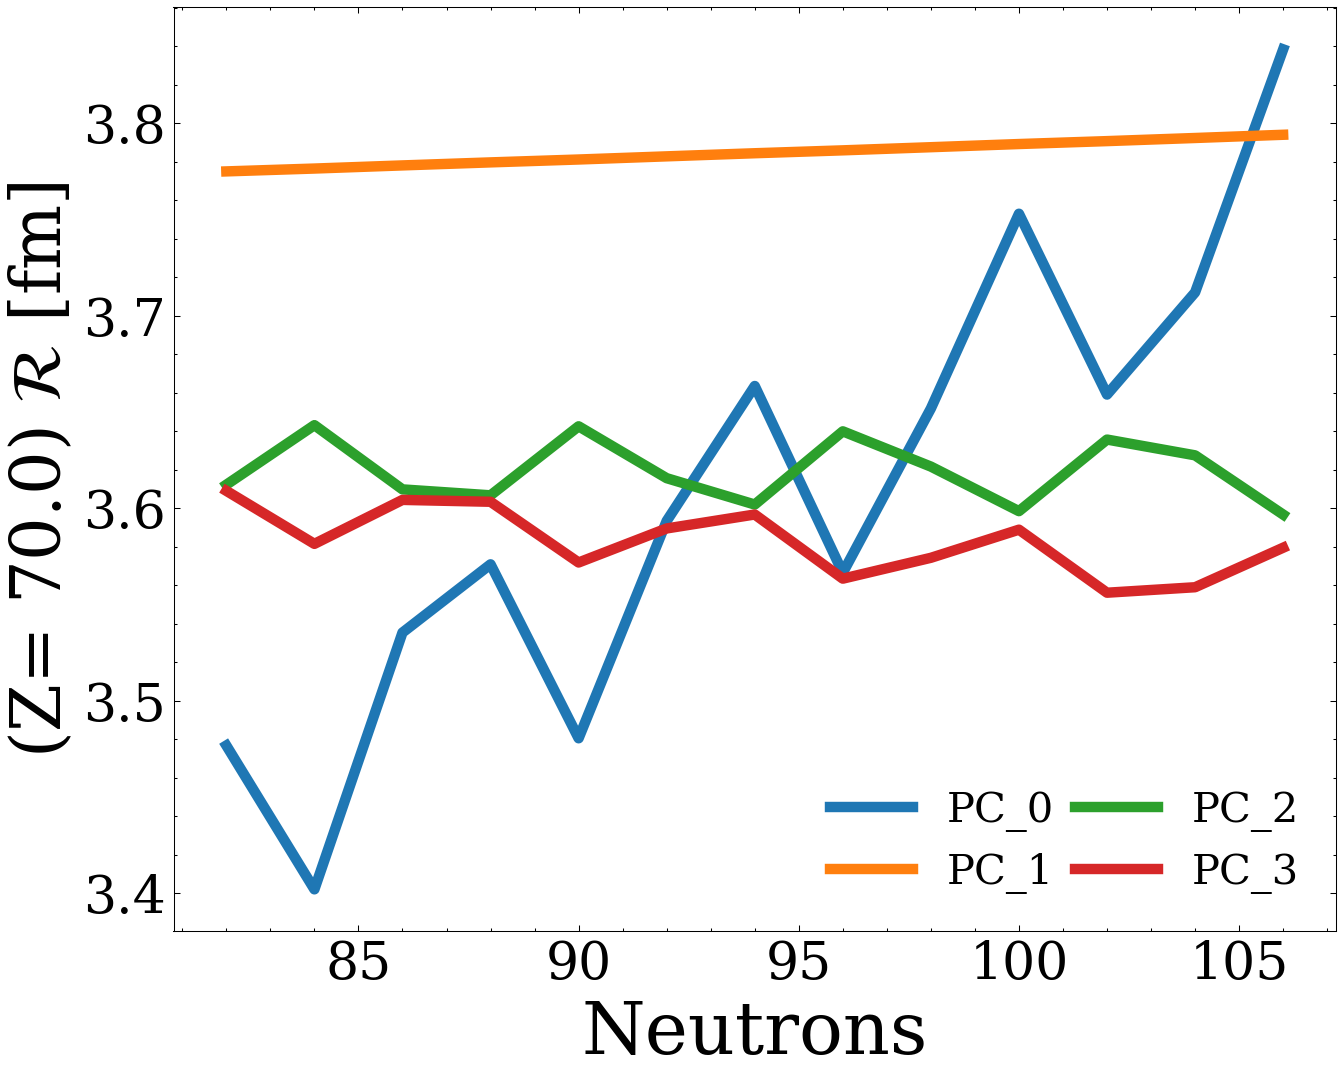

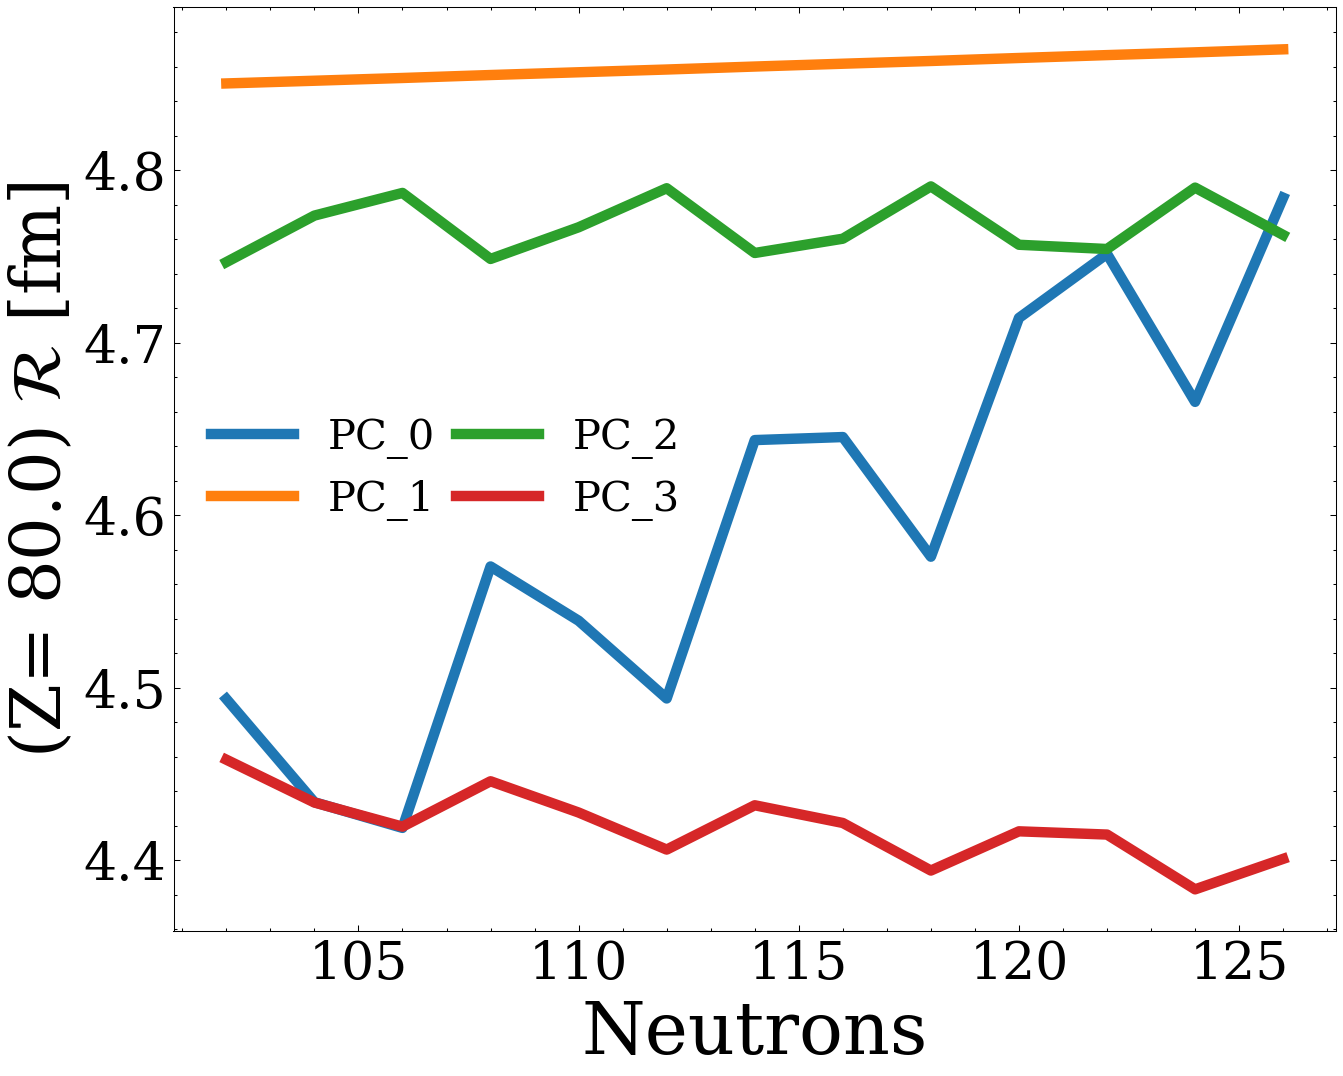

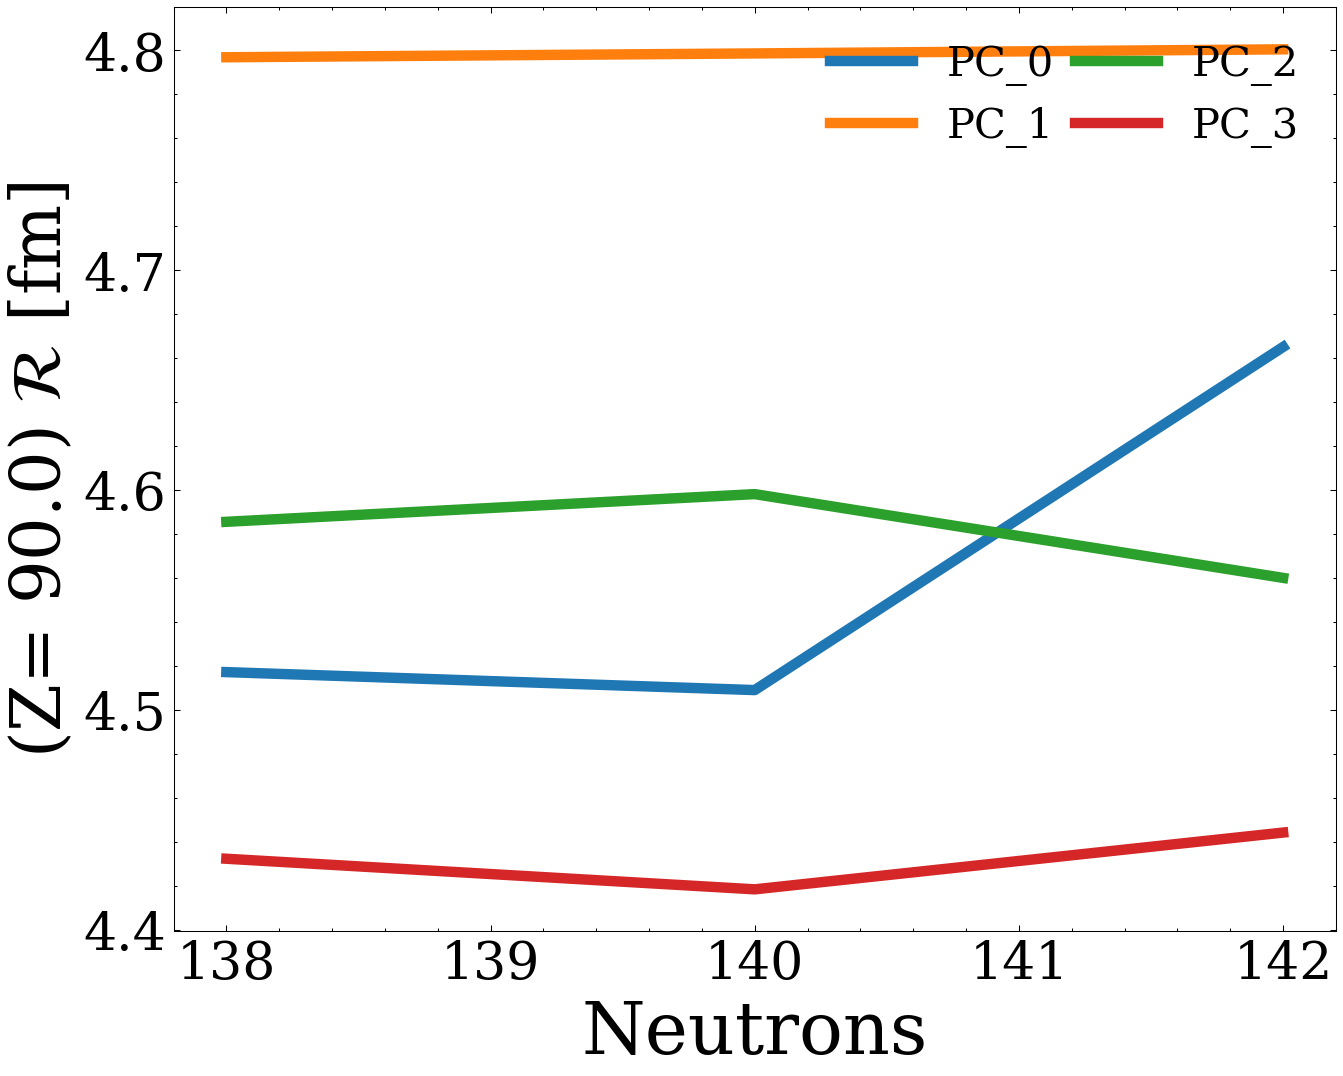

In [528]:
for i in range(len(Selected_elements_list)):
    plot_filtered_something_else_dict(Selected_elements_list, Selected_elements_list[i], x[i], filtered_models_output_radius_dict_fake,\
                                      scaled_filtered_models_PC_radius_dict_fake, ['PC_0', 'PC_1', 'PC_2', 'PC_3'])
    # plt.savefig(f'Plots/Fake models analysis/PCs Visualizations - Radii/{Selected_elements_list[i]}')
    plt.show()

In [529]:
# We will now perform some naive combination scheme to see if the first few PCs give us soem important information about the data set

In [530]:
super_params_fake_train = super_params(model_predictions_radius_fake_train, models_output_radius_fake_train['truth'])
supermodel_radius_fake_train = super_params_fake_train.dot(model_predictions_radius_fake_train.T)
supermodel_radius_fake_validation = super_params_fake_train.dot(model_predictions_radius_fake_validation.T)
supermodel_radius_fake_test = super_params_fake_train.dot(model_predictions_radius_fake_test.T)
supermodel_radius_fake_full = super_params_fake_train.dot(model_predictions_radius_fake.T)

supermodel_residuals_radius_fake_train=supermodel_radius_fake_train-models_output_radius_fake_train['truth'].tolist()
supermodel_residuals_radius_fake_validation= supermodel_radius_fake_validation-models_output_radius_fake_validation['truth'].tolist()
supermodel_residuals_radius_fake_test = supermodel_radius_fake_test-models_output_radius_fake_test['truth'].tolist()
supermodel_residuals_radius_fake_full = supermodel_radius_fake_full-models_output_radius_fake['truth'].tolist()

supermodel_sigma_radius_fake_train=np.sqrt(np.sum(supermodel_residuals_radius_fake_train**2) / len(supermodel_residuals_radius_fake_train) )
supermodel_sigma_radius_fake_validation=np.sqrt(np.sum(supermodel_residuals_radius_fake_validation**2) / len(supermodel_residuals_radius_fake_validation) )
supermodel_sigma_radius_fake_test=np.sqrt(np.sum(supermodel_residuals_radius_fake_test**2) / len(supermodel_residuals_radius_fake_test) )
supermodel_sigma_radius_fake_full=np.sqrt(np.sum(supermodel_residuals_radius_fake_full**2) / len(supermodel_residuals_radius_fake_full) )

In [531]:
model_predictions_radius_fake_train

array([[2.40477685, 1.12961363, 2.02616496, ..., 2.74567814, 2.4588852 ,
        1.96469754],
       [2.40477685, 1.4083424 , 2.52693371, ..., 3.13642394, 2.57255063,
        2.08940079],
       [2.67151776, 1.3705072 , 2.46639728, ..., 3.28084225, 2.61760077,
        2.11930835],
       ...,
       [1.20364753, 1.33319742, 6.1621863 , ..., 4.61446873, 5.59898734,
        5.76732561],
       [1.20298634, 1.20729503, 5.97341134, ..., 4.45541433, 5.40755415,
        5.63501175],
       [1.20298634, 1.3086177 , 6.30466573, ..., 4.60862655, 5.47177903,
        5.73126554]])

In [532]:
if centering_data:
    s_radius_fake_validation=[np.linalg.norm(np.array(models_output_radius_fake_validation["truth"].tolist())-predictions_mean_radius_fake_validation)/np.sqrt(len(predictions_mean_radius_fake_validation))]
    s_radius_fake_test=[np.linalg.norm(np.array(models_output_radius_fake_test["truth"].tolist())-predictions_mean_radius_fake_test)/np.sqrt(len(predictions_mean_radius_fake_test))]
    s_radius_fake_train=[np.linalg.norm(np.array(models_output_radius_fake_train["truth"].tolist())-predictions_mean_radius_fake_train)/np.sqrt(len(predictions_mean_radius_fake_train))]
    s_radius_fake_all=[np.linalg.norm(np.array(models_output_radius_fake["truth"].tolist())-predictions_mean_radius_fake)/np.sqrt(len(predictions_mean_radius_fake))]

if centering_data:
    for i in range(1,len(S_fake)):
        res=PC_RMSE_calculator(i, model_predictions_radius_fake_train, predictions_mean_radius_fake_train, models_output_radius_fake_train, models_output_radius_list_fake, model_predictions_radius_list_fake, U_fake, S_fake, Vt_fake)
        s_radius_fake_all.append(res[0])
        s_radius_fake_train.append(res[1])
        s_radius_fake_validation.append(res[2])
        
        s_radius_fake_test.append(res[3])

[-0.07784184 -0.09322844  0.15502328  0.2260871   0.10849002  0.0967835
  0.1116594   0.14375823  0.16534739  0.16392136]
0.5287937551415401
[-0.08037667 -0.09253847  0.1747766   0.22031941  0.1287094   0.08931588
  0.09611483  0.14742516  0.15124655  0.16500731]
0.5266210636424385
[-0.02656114 -0.14543367  0.18611406  0.18715055  0.08554291  0.05790405
  0.10691764  0.26395399  0.13998159  0.14443003]
0.5063931038267023
[-0.03187648 -0.14257476  0.18724468  0.18105719  0.08368143  0.06143141
  0.10646159  0.2666328   0.14193666  0.14600548]
0.5063719402908372
[-0.1799777   0.20846624 -0.16626304  0.54585769  0.09755336 -0.08871818
 -0.40425238  0.64249999  0.29412449  0.05070953]
0.42682848237260246
[-0.14988581 -0.15471871 -0.49431655  0.66172242  0.46475827  1.09209085
 -0.56058955  0.84769616 -0.15546382 -0.55129326]
0.0836768358286905
[-0.15677853 -0.13865077 -0.45672127  0.68336609  0.43224911  1.09777978
 -0.56001393  0.84394884 -0.16322425 -0.58195506]
0.08316395717811627
[-5.0

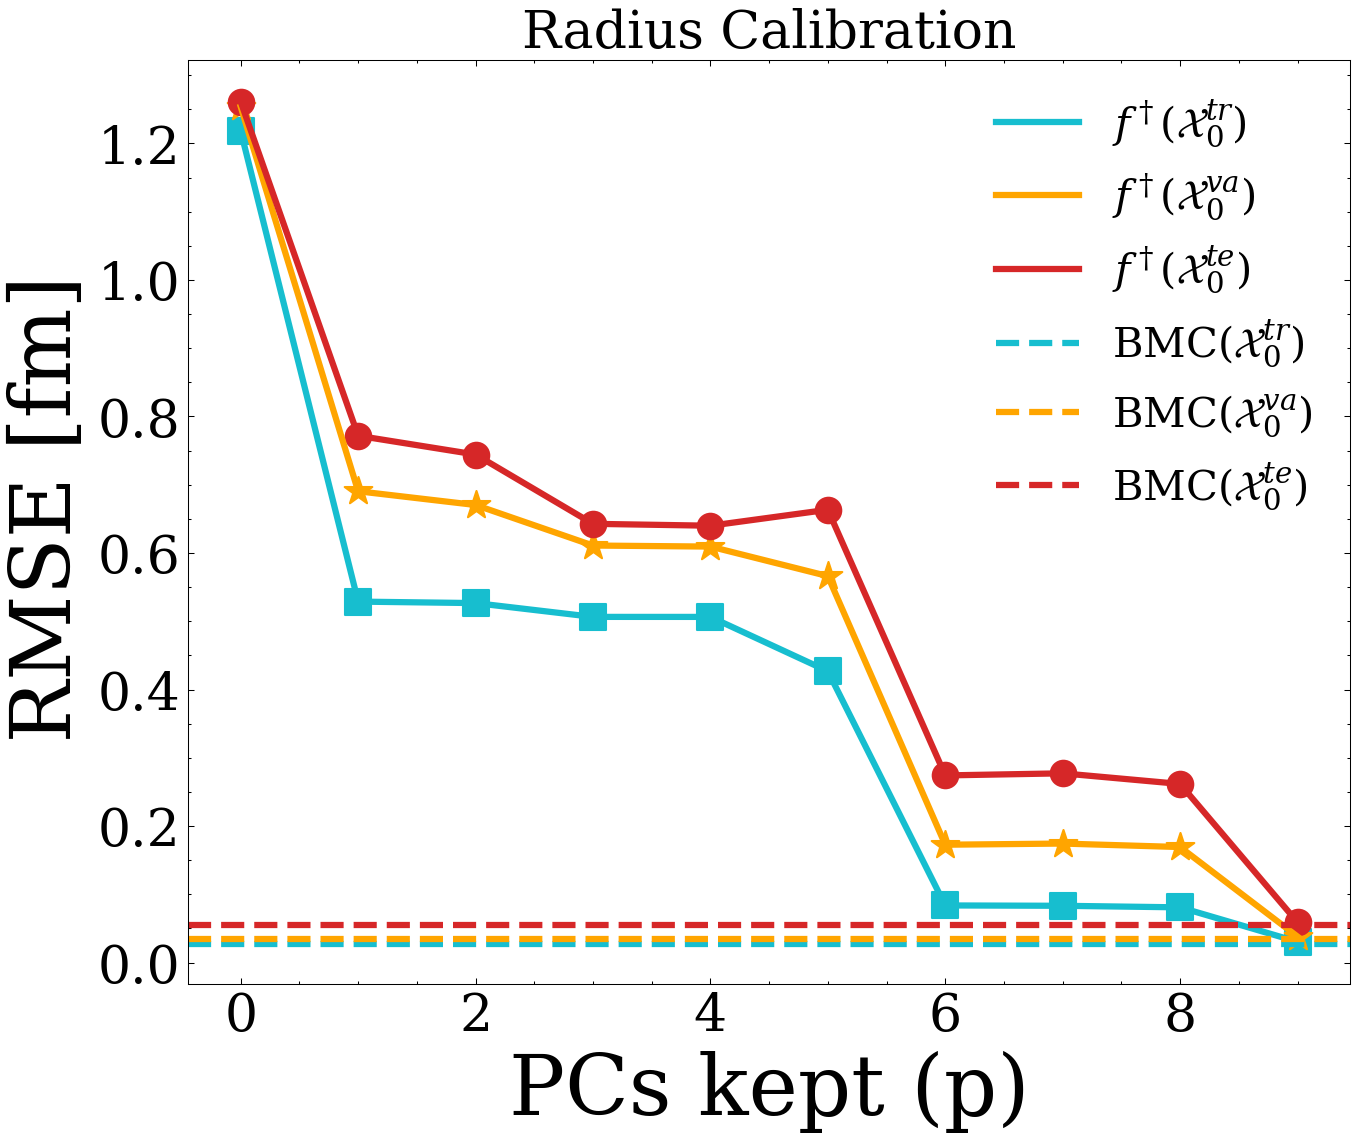

In [533]:
plt.rc("xtick", labelsize=25)
plt.rc("ytick", labelsize=25)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_radius_fake_train)), s_radius_fake_train,color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_radius_fake_train)), s_radius_fake_train,color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_radius_fake_validation)), s_radius_fake_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_radius_fake_validation)), s_radius_fake_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_radius_fake_test)), s_radius_fake_test,color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_radius_fake_test)), s_radius_fake_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

ax.axhline(y=supermodel_sigma_radius_fake_train,color=color_train,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)
ax.axhline(y=supermodel_sigma_radius_fake_validation,color=color_validation,label="BMC$(\mathcal{X}_0^{va})$",linestyle='dashed',linewidth=3)
ax.axhline(y=supermodel_sigma_radius_fake_test,color=color_test,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'PCs kept (p)',fontsize=40)
ax.set_ylabel(r' RMSE [fm]',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=20)
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.title('Radius Calibration', fontsize = 25)
# plt.savefig('Plots/Heterogeneous Real Scaled Analysis/RMSE decays/Radius RMSE decay - Radius Analysis.png')
# plt.legend(fontsize=30)
plt.show()

## What we want to do before meeting with professor Witek is to calculate the residuals of the LDM model for both mass and radii and graph this surface out to see if we should see any different characteristics of this surface.

In [691]:
A_radii_power_onethird = A_radii ** (0.33)
LDM_radii_param = super_params(A_radii_power_onethird[:, None],models_output_radius['truth'])
LDM_radii = LDM_radii_param.item() * A_radii_power_onethird

In [692]:
LDM_radii

array([2.41331502, 2.50896353, 2.50896353, 2.59773186, 2.68073514,
       2.75882487, 2.83266768, 2.90279638, 2.75882487, 2.83266768,
       2.90279638, 2.96964432, 3.03356926, 3.09487038, 3.15380071,
       3.03356926, 3.09487038, 3.15380071, 3.2105764 , 3.26538369,
       3.31838436, 3.36971992, 3.41951495, 3.26538369, 3.31838436,
       3.36971992, 3.41951495, 3.46787975, 3.51491254, 3.36971992,
       3.41951495, 3.46787975, 3.51491254, 3.51491254, 3.56070115,
       3.60532452, 3.60532452, 3.64885387, 3.69135369, 3.69135369,
       3.73288263, 3.77349414, 3.81323713, 3.81323713, 3.85215648,
       3.89029346, 3.92768613, 3.92768613, 3.96436968, 4.0003767 ,
       4.03573747, 4.0003767 , 4.03573747, 4.07048015, 4.10463097,
       4.13821445, 3.96436968, 4.0003767 , 4.03573747, 4.07048015,
       4.10463097, 4.13821445, 4.17125352, 4.20376965, 4.23578301,
       4.26731252, 4.29837602, 4.32899031, 4.35917123, 4.07048015,
       4.10463097, 4.13821445, 4.17125352, 4.20376965, 4.23578

In [693]:
LDM_radii_residuals = models_output_radius['truth'] - LDM_radii

In [694]:
def LDM_extended(params, N, Z): 
    #x = (n,z)
    #params= parameters (volume, surface, curv, sym, ssym, sym_2, Coulomb)
    
    A = N + Z
    I = (N-Z)/(N+Z)


    return A*params[0] + params[1] * A ** (2/3) + params[2] * A ** (1/3)  +  params[3] * I ** 2*A + \
                + params[4] * (I ** 2) * A ** (2/3) + params[5] * (I ** 4)*A + params[6]*((Z**2)/((A)**(1/3))) 

In [587]:
I_mass = (models_output_mass['N'] - models_output_mass['Z'])/(models_output_mass['N'] + models_output_mass['Z'])
LDM_mass_dataset = {}
LDM_mass_dataset['A'] = models_output_mass['A']
LDM_mass_dataset['A^(2/3)'] = models_output_mass['A']**(2/3)
LDM_mass_dataset['A^(1/3)'] = models_output_mass['A']**(1/3)
LDM_mass_dataset['I^2 * A'] = I_mass**2 * models_output_mass['A']
LDM_mass_dataset['I^2 * A^(2/3)'] = (I_mass**2) * (models_output_mass['A'] ** (2/3))
LDM_mass_dataset['I^4 * A'] = (I_mass**4) * models_output_mass['A']
LDM_mass_dataset['Z^2/A^(1/3)'] = (models_output_mass['Z']**2) / (models_output_mass['A']**(1/3))

In [588]:
LDM_mass_dataset = pd.DataFrame(LDM_mass_dataset)

In [590]:
LDM_mass_param = super_params(LDM_mass_dataset.values, models_output_mass['truth'])

In [609]:
LDM_mass = LDM_mass_dataset.values.dot(LDM_mass_param)
LDM_mass_residuals = models_output_mass['truth'] - LDM_mass

### The next step is to graph the residuals, both 2D and 3D out and evaluate the surface of residuals

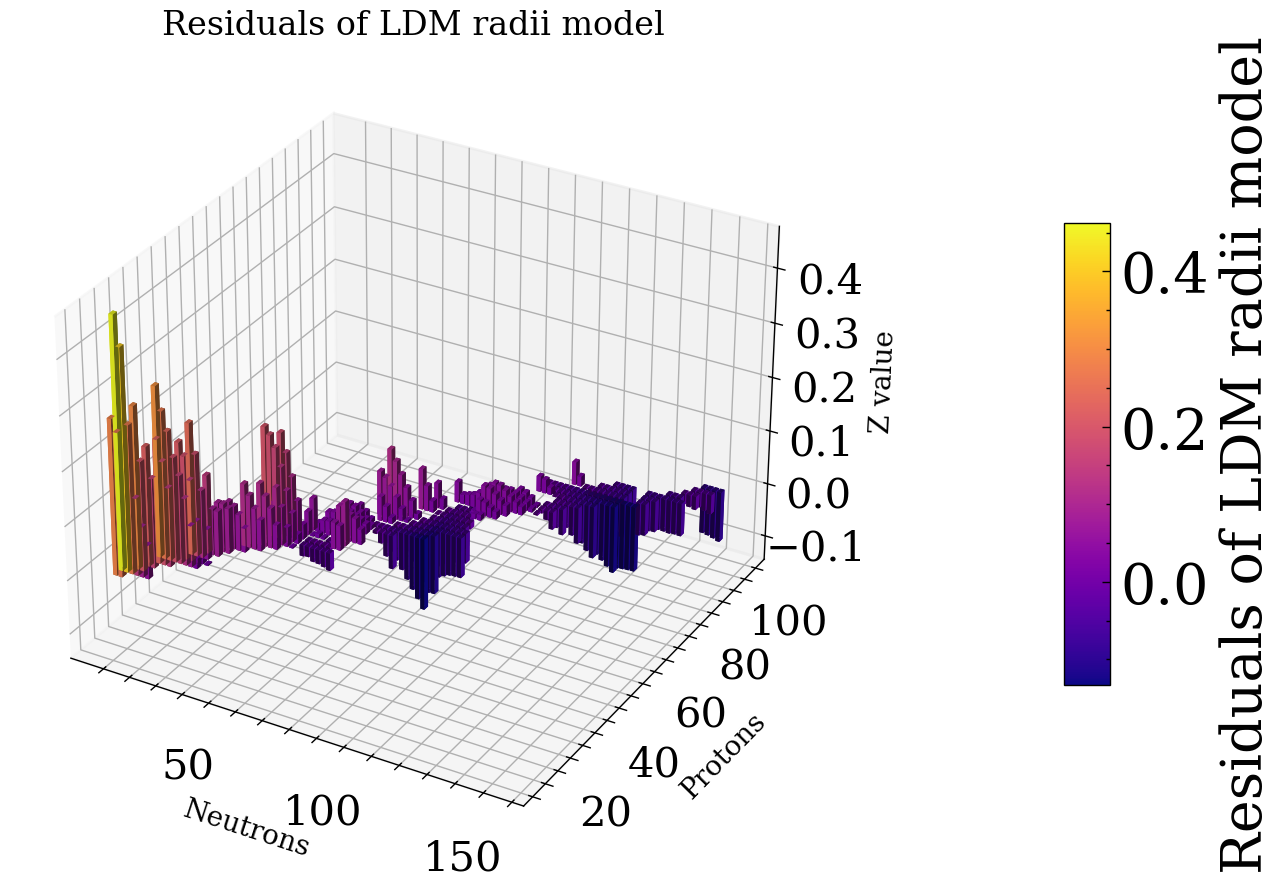

In [696]:
Plotter3D_single(models_output_radius['N'], models_output_radius['Z'], LDM_radii_residuals, 'Residuals of LDM radii model')
plt.savefig('Plots/Radii data/PCs 3D heat map - Radii/Residuals of LDM radii model.png')
plt.show()

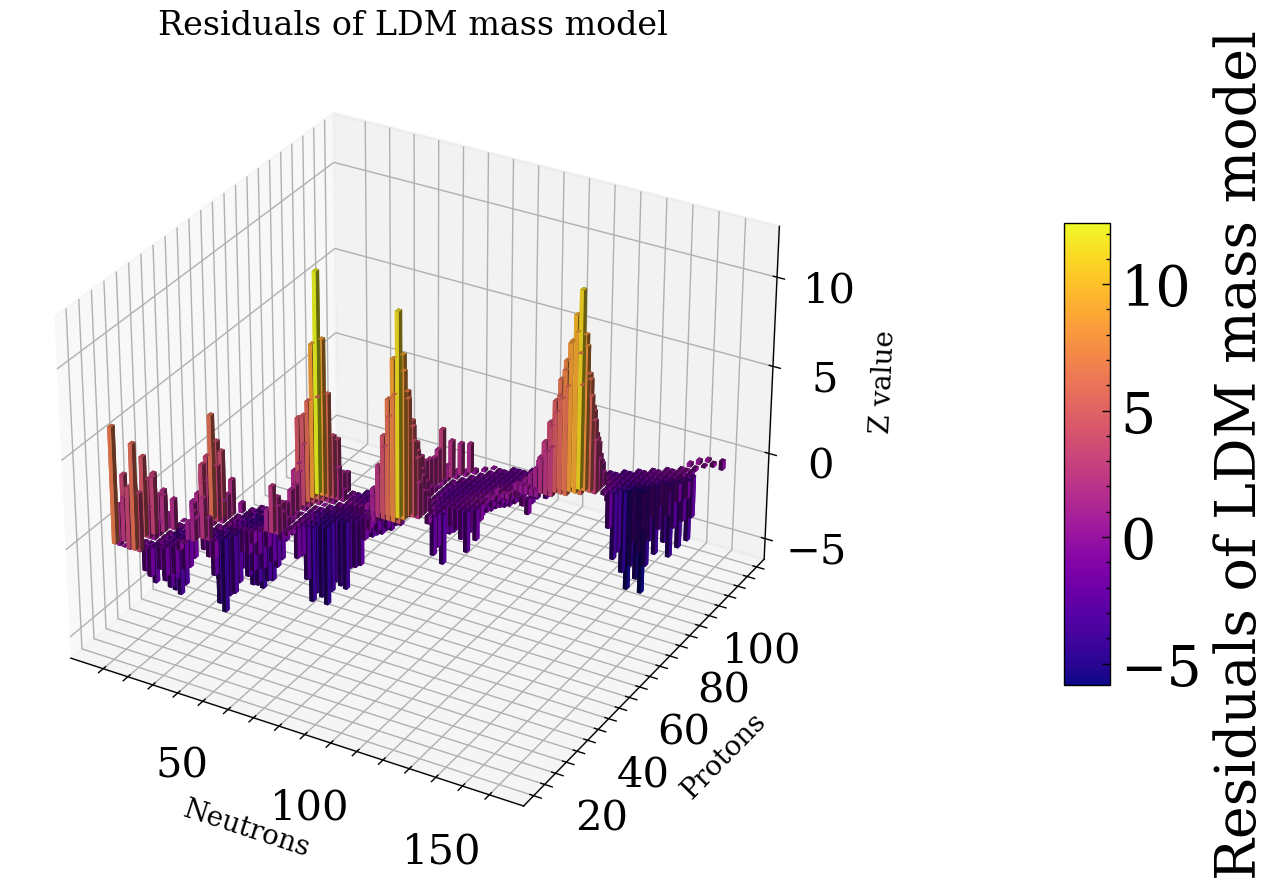

In [624]:
Plotter3D_single(models_output_mass['N'], models_output_mass['Z'], LDM_mass_residuals, 'Residuals of LDM mass model')
plt.savefig('Plots/Radii data/PCs 3D heat map - Mass/Residuals of LDM mass model.png')
plt.show()

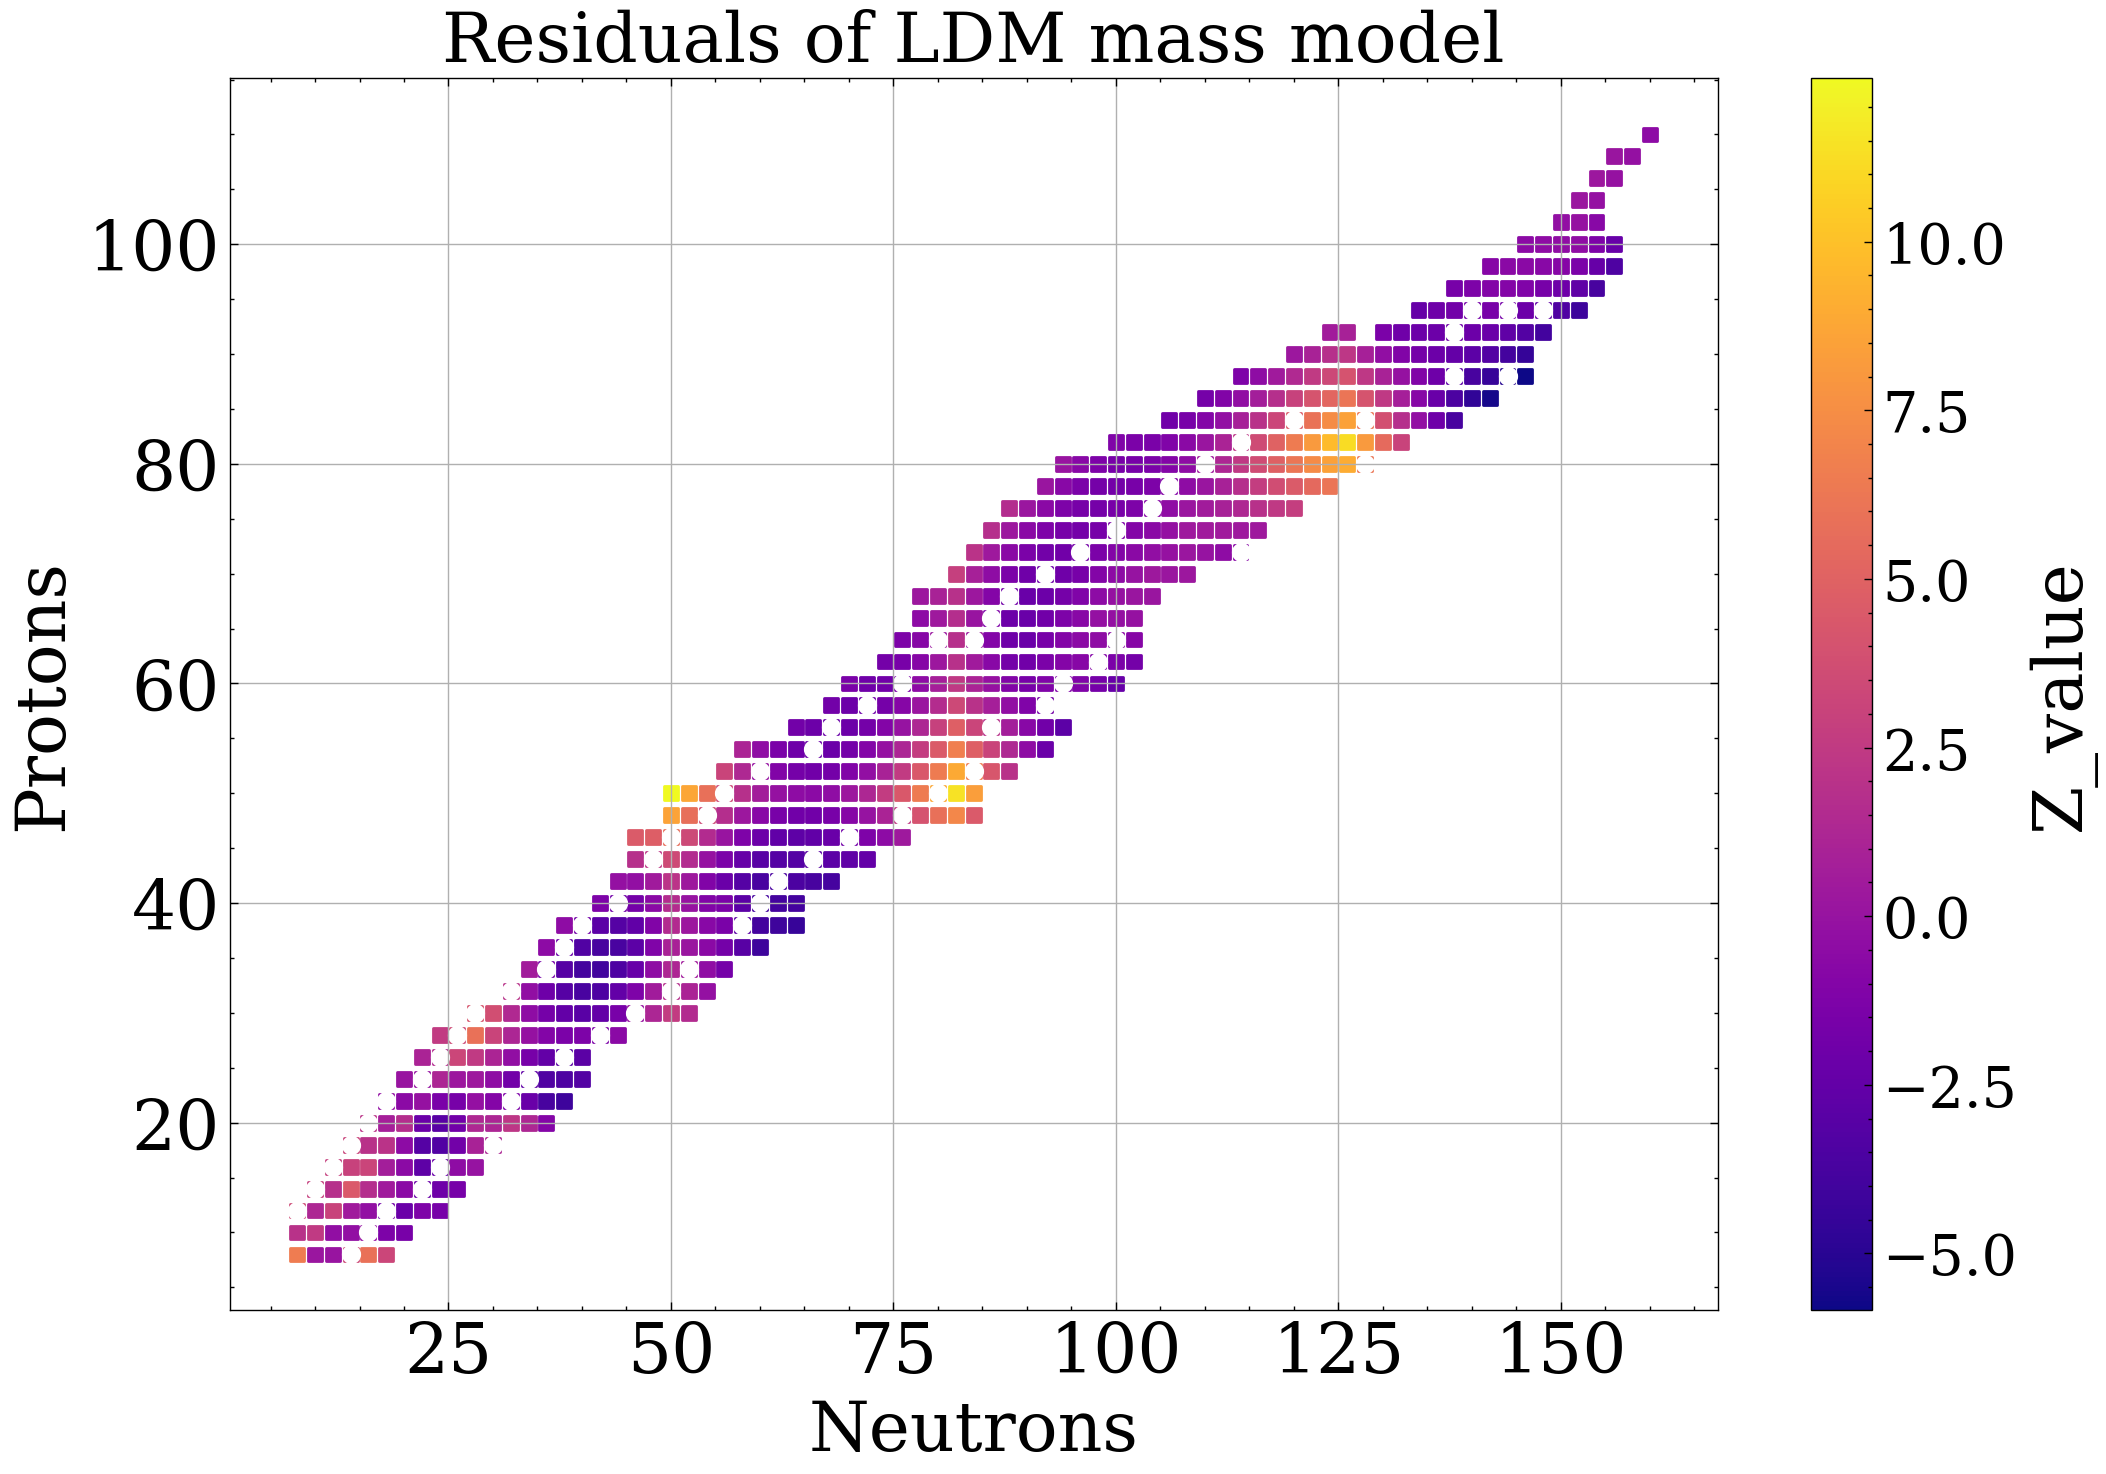

In [677]:
Plotter2D_single(models_output_mass['N'], models_output_mass['Z'], LDM_mass_residuals, validation_set_mass, 'Z_value', 'Residuals of LDM mass model')
# plt.savefig('Plots/Radii data/PCs heat map - Mass/Residuals of LDM mass model.png')
plt.show()

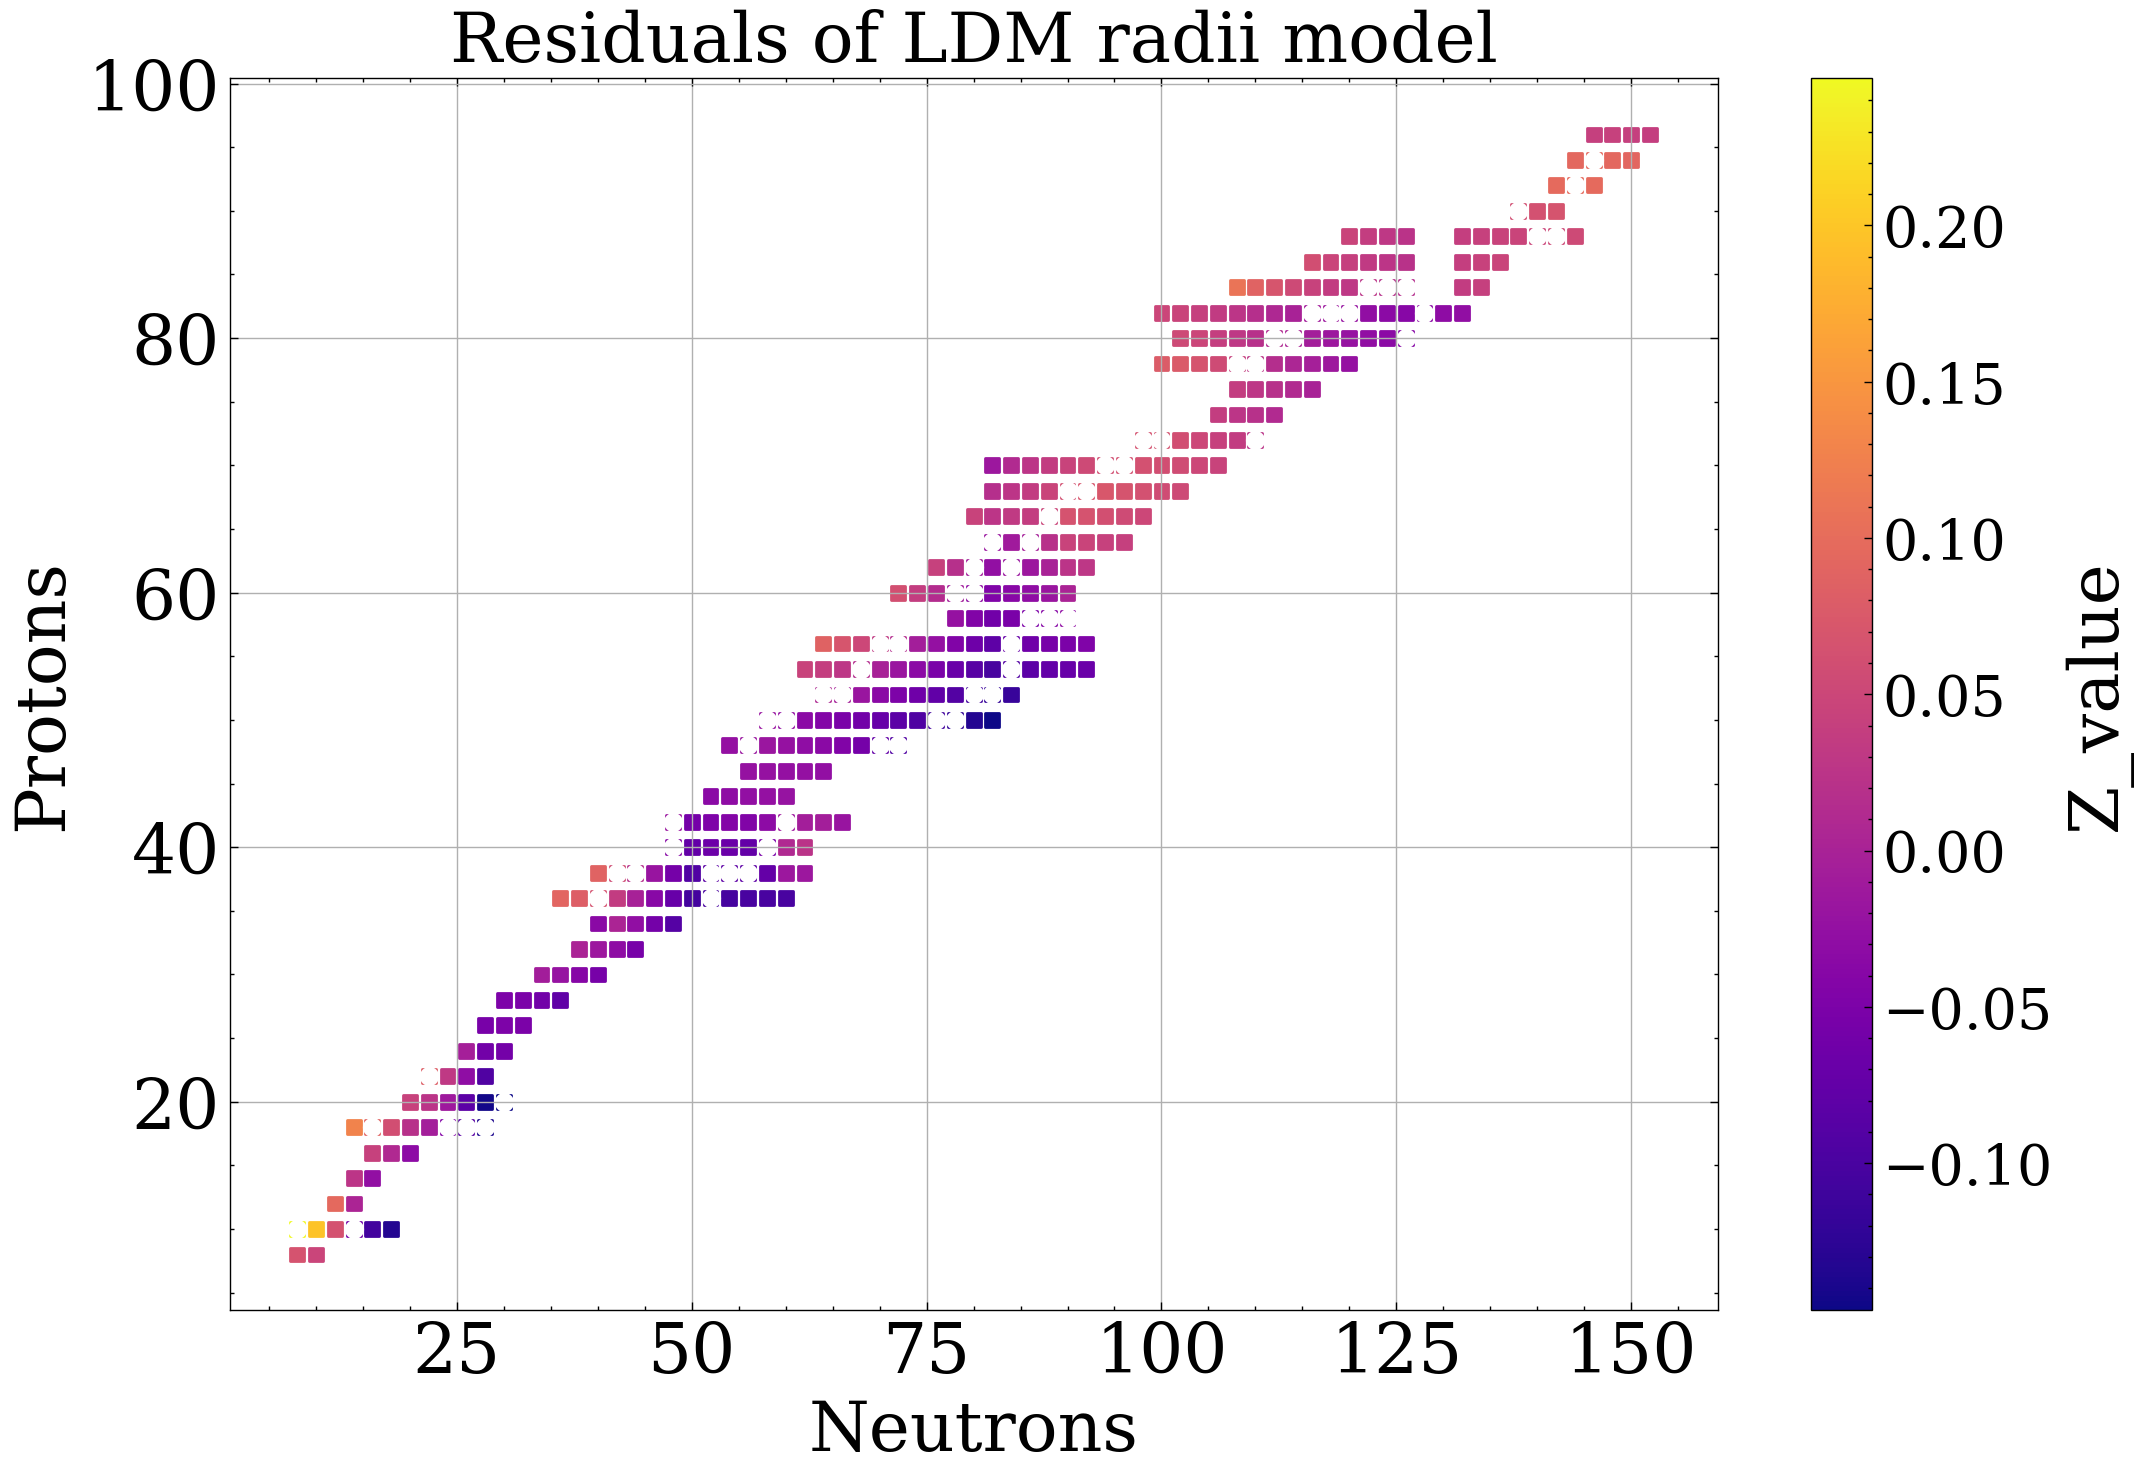

In [678]:
Plotter2D_single(models_output_radius['N'], models_output_radius['Z'], LDM_radii_residuals, validation_set_radius, 'Z_value', 'Residuals of LDM radii model')
# plt.savefig('Plots/Radii data/PCs heat map - Radii/Residuals of LDM radii model.png')
plt.show()

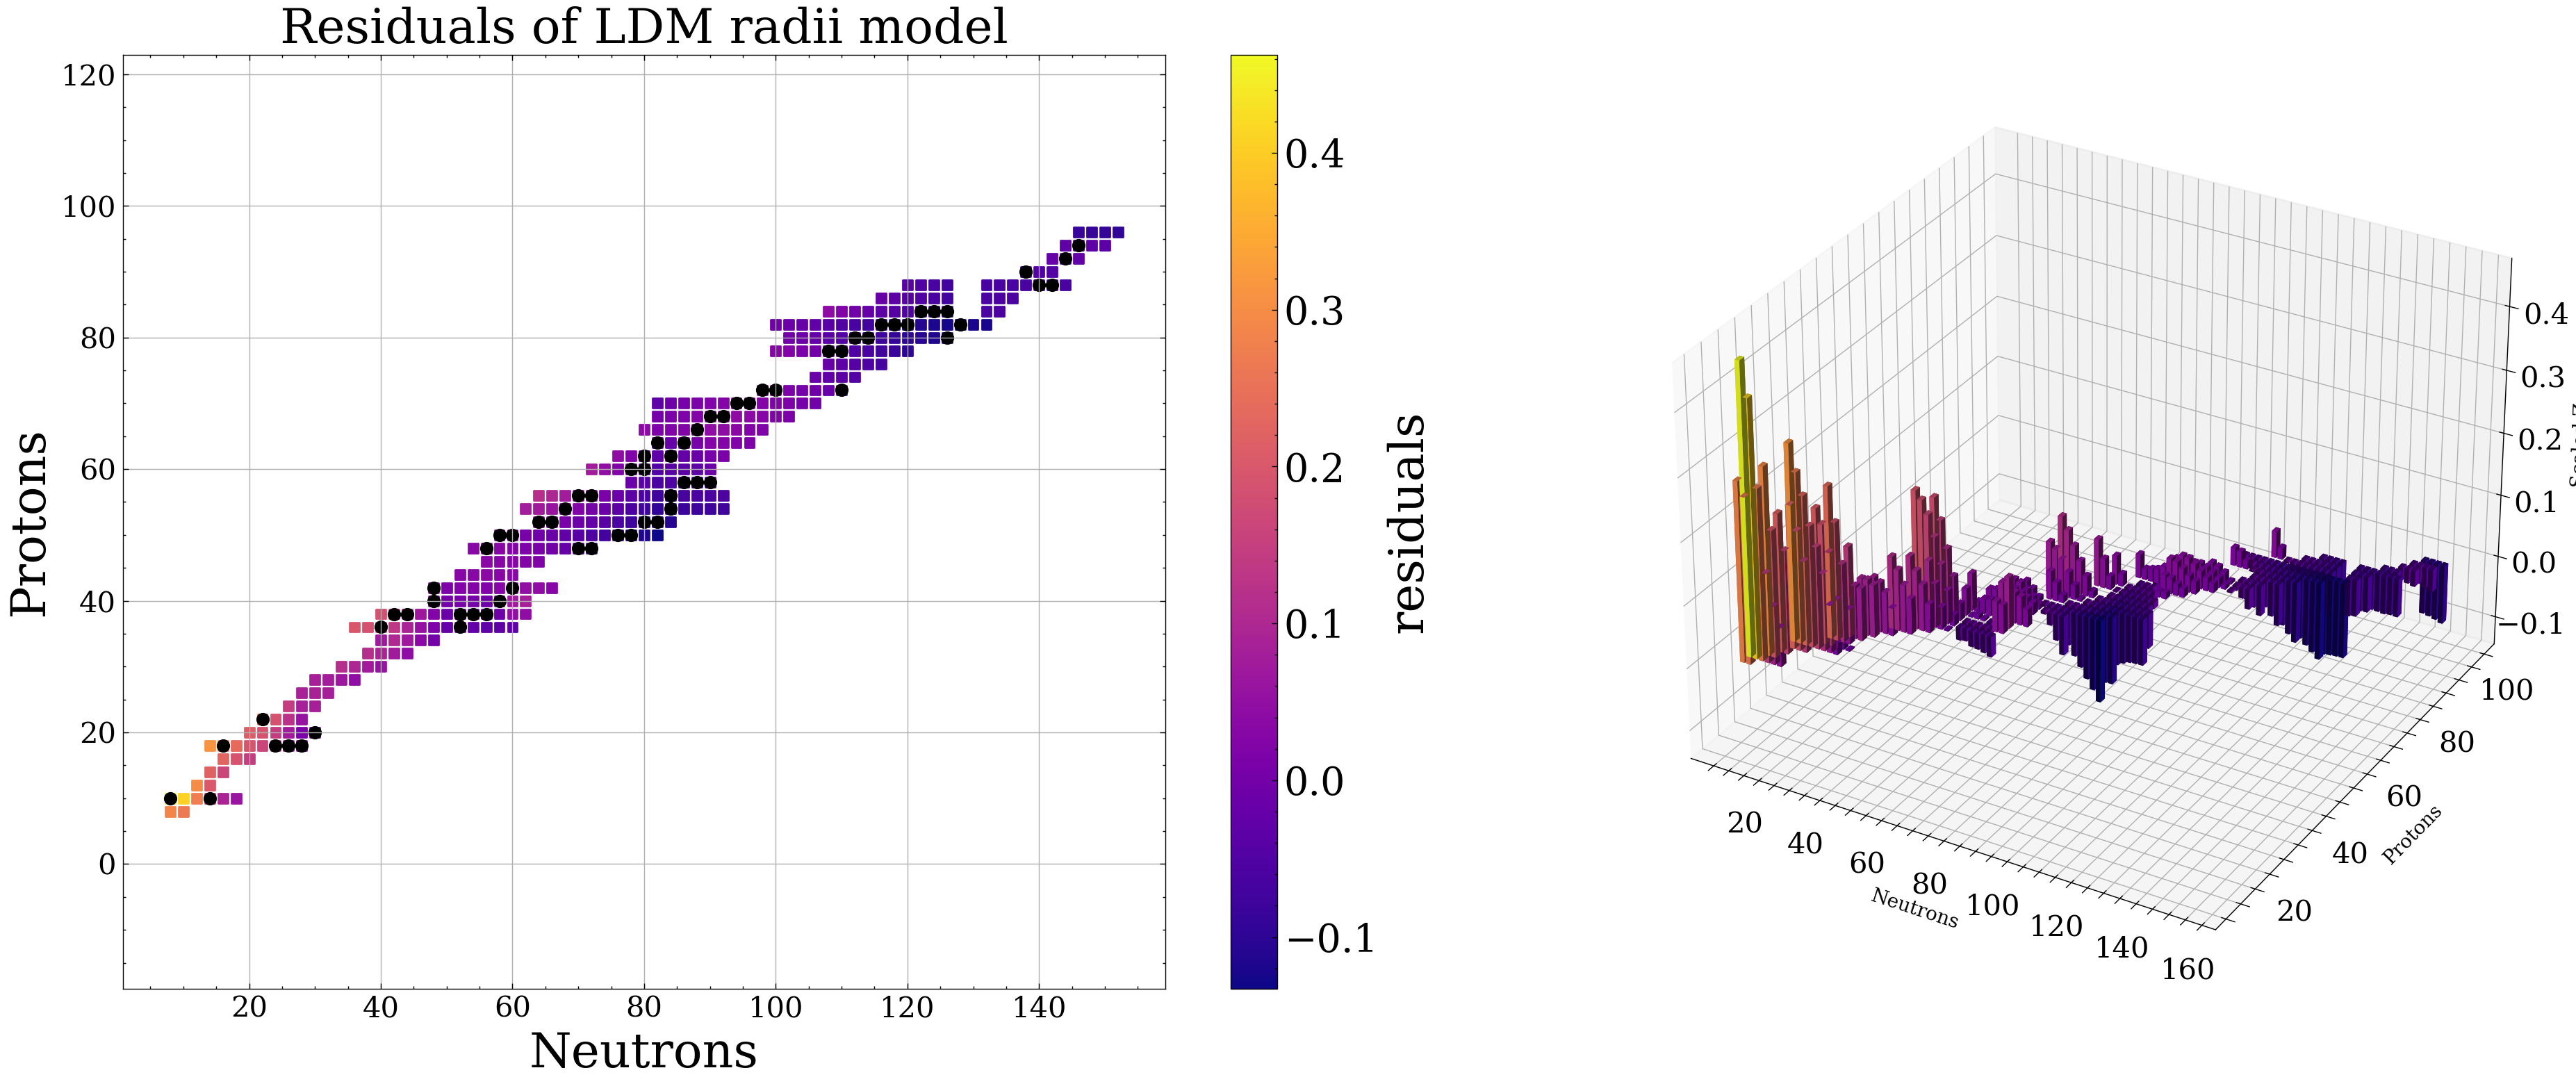

In [697]:
PlotMultiple(models_output_radius['N'], models_output_radius['Z'], LDM_radii_residuals, validation_set_radius, 'residuals','Residuals of LDM radii model', [30, -60])
plt.savefig('Plots/Radii data/Combined heat map - Radii/Residuals of LDM radii model.png')
plt.show()

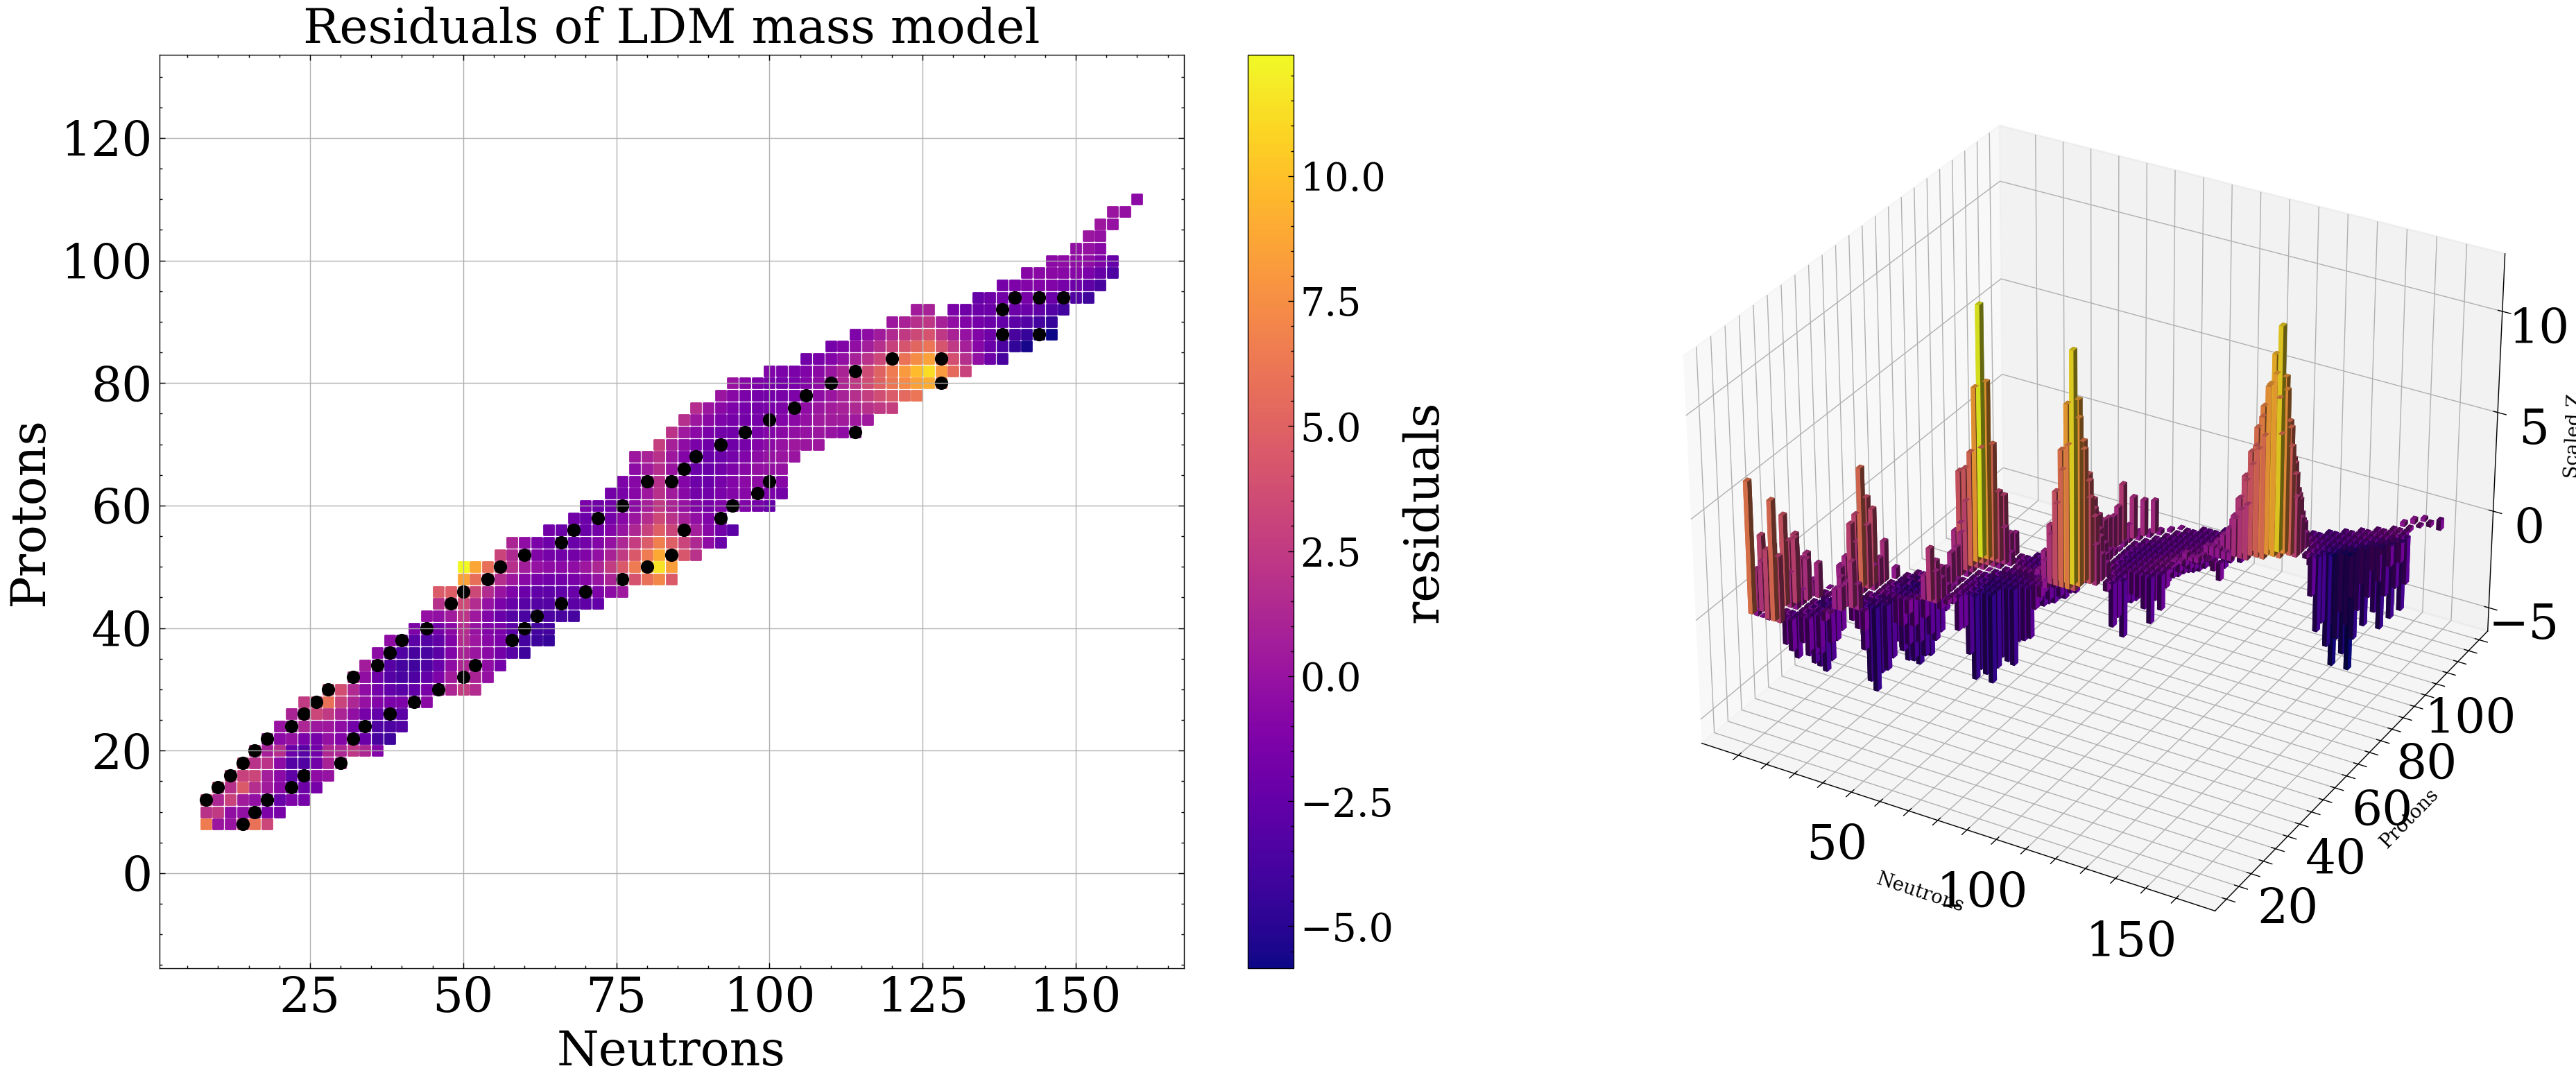

In [690]:
PlotMultiple(models_output_mass['N'], models_output_mass['Z'], LDM_mass_residuals, validation_set_mass, 'residuals','Residuals of LDM mass model', [30, -60])
plt.savefig('Plots/Radii data/Combined heat map - Mass/Residuals of LDM mass model.png')
plt.show()